# V0 topology QA composer — fixed PDF export

Edit only `PLOTS` (and, if needed, `SPECIES` / `PT_BINS`), then run the notebook.

This version keeps all canvases alive, forces pad/canvas updates, creates the multipage PDF with ROOT's `(` / `)` syntax, and writes canvases to the output ROOT file only **after** the PDF is made.

- `"variable:all"` → peak + scaled sideband + signal (`peak - scaled sideband`)
- `"variable:sg"` → signal only
- `"variable:bg"` → scaled sideband only
- `"variable:pk"` → peak only
- add `":pt"` → repeat in every mother-$p_T$ bin, when available

`dphi` uses the **pre-$\Delta\phi$-cut** mass-vs-$\Delta\phi$ histogram.


In [ ]:
import ROOT as root
from IPython.display import display
from pathlib import Path
import itertools, re

# ------------------------- EDIT THIS -------------------------
FILE = "input/v0_topology_qa.root"#kshort_topology_qa_tsallis_noquality_nodedx
FILE_SIM = "input/kshort_topology_qa_tsallis_noquality_nodedx.root"
SPECIES = ["K0s", "Lambda"]       # optionally add "AntiLambda"
PT_BINS = [(0,.5),(.5,1),(1,1.5),(1.5,2),(2,3),(3,5)]

PLOTS = [
    "dphi:all",          # PRE-cut dphi, integrated pT
    "dcaxy_min:all",
    "dcaz+:sg",
    "dcaz-:sg",
    "pairdca:all",
    "decayr:all",
    "dira:sg",
    "opening:sg",
    "alpha:all",
    "qt:all",

    # pT-binned examples; delete any you do not want
    "pairdca:all:pt",
    "decayr:sg:pt",
    "dira:sg:pt",
    "opening:sg:pt",
    # "dphi_post:all:pt",   # available, but AFTER the signed-dphi cut
]


PLOTS = [
    "dphi:sg",          # PRE-cut dphi, integrated pT
    #"dcaxy_min:all",
    "pairdca:pk",
    "dpcaz:pk",
    "decayr:sg",
    "dira:pk",
    "alpha:pk",
    "npoints_min:pk",
    "npoints_max:pk",

    # pT-binned examples; delete any you do not want
    "pairdca:pk:pt",
    "decayr:sg:pt",
    "dira:pk:pt",
    "dpcaz:pk:pt",
    #"dphi_post:sg:pt",   # available, but AFTER the signed-dphi cut
]

PLOTS = [
    "dphi:all",          # PRE-cut dphi, integrated pT
    #"dcaxy_min:all",
    "pairdca:all",
    "dpcaz:all",
    "decayr:all",
    "dira:all",
    "alpha:all",
    "npoints_min:all",
    "npoints_max:all",

    # pT-binned examples; delete any you do not want
    "pairdca:pk:pt",
    "decayr:sg:pt",
    "dira:pk:pt",
    "dpcaz:pk:pt",
    #"dphi_post:sg:pt",   # available, but AFTER the signed-dphi cut
]
# ------------------------------------------------------------

PDF = "output/v0_topology_plots/v0_topology_QA_sim.pdf"
ROOT_OUT = "output/v0_topology_plots/v0_topology_QA_sim.root"
SHOW = False                      # True -> also display every canvas in notebook

root.gStyle.SetOptStat(0)
root.TH1.AddDirectory(False)
f = root.TFile.Open(FILE)
assert f and not f.IsZombie(), f"Cannot open {FILE}"
fout = root.TFile(ROOT_OUT, "RECREATE")
assert not fout.IsZombie()

_n = itertools.count()
KEEP = []


Welcome to JupyROOT 6.30/06


## Available short names

Delete/add entries in `PLOTS` using these names. You can also print `ALIASES` below at any time.


In [2]:
# Integrated peak/sideband objects.
# kind: h1 / h2 / pre_dphi
ALIASES = {
    "pt":            ("h_v0_pt", "h1"),
    "eta":           ("h_v0_eta", "h1"),
    "decayr":        ("h_decay_radius", "h1"),
    "decayphi":      ("h_decay_phi", "h1"),
    "pcaz":          ("h_pca_z", "h1"),
    "dpcaz":         ("h_abs_delta_pca_z", "h1"),
    "dpca3d":        ("h_delta_pca_3d", "h1"),
    "pairdca":       ("h_pairDCA", "h1"),
    "dira":          ("h_DIRA", "h1"),
    "logdira":       ("h_log10_one_minus_DIRA", "h1"),
    "alpha":         ("h_alpha", "h1"),
    "qt":            ("h_qT", "h1"),
    "opening":       ("h_opening_angle", "h1"),

    # dphi means PRE CUT by design
    "dphi":          ("h_mass_vs_delta_phi_pre_cut", "pre_dphi"),
    "dphi_post":     ("h_delta_phi", "h1"),
    "absdphi":       ("h_abs_delta_phi", "h1"),
    "deta":          ("h_delta_eta", "h1"),
    "absdeta":       ("h_abs_delta_eta", "h1"),
    "dtheta":        ("h_delta_theta", "h1"),
    "dphi_deta_ratio": ("h_abs_dphi_over_abs_deta", "h1"),

    "ptasym":        ("h_pt_asymmetry_signed", "h1"),
    "absptasym":     ("h_pt_asymmetry_abs", "h1"),
    "pasym":         ("h_p_asymmetry_signed", "h1"),
    "abspasym":      ("h_p_asymmetry_abs", "h1"),

    "dcaxy+":        ("h_dca_xy_positive", "h1"),
    "dcaxy-":        ("h_dca_xy_negative", "h1"),
    "dcaxy_min":     ("h_min_abs_dca_xy", "h1"),
    "dcaxy_prod":    ("h_abs_dca_xy_product", "h1"),
    "dcaz+":         ("h_dca_z_positive", "h1"),
    "dcaz-":         ("h_dca_z_negative", "h1"),

    "npoints_min":   ("h_npoints_min", "h1"),
    "npoints_max":   ("h_npoints_max", "h1"),
    "quality_min":   ("h_quality_min", "h1"),
    "quality_max":   ("h_quality_max", "h1"),
    "pt_heavy_light":("h_pt_heavy_over_light", "h1"),
    "p_heavy_light": ("h_p_heavy_over_light", "h1"),

    # integrated 2D QA
    "pt_posneg":     ("h_pt_positive_vs_pt_negative", "h2"),
    "alpha_qt":      ("h_alpha_vs_qT", "h2"),
    "dphi_deta":     ("h_abs_delta_phi_vs_abs_delta_eta", "h2"),
    "pairdca_r":     ("h_pairDCA_vs_decayR", "h2"),
    "dira_r":        ("h_DIRA_vs_decayR", "h2"),
    "npoints_r":     ("h_npoints_min_vs_decayR", "h2"),
    "opening_pt":    ("h_opening_vs_v0_pt", "h2"),
    "decayphi_r":    ("h_decay_phi_vs_radius", "h2"),
}

# Objects with mass x mother-pT x variable, so true peak/sideband subtraction
# can be repeated independently in each pT bin.
PT_MASS3 = {
    "dphi_post": "h_delta_phi_vs_mass_vs_pt",
    "decayr":    "h_decay_radius_vs_mass_vs_pt",
    "opening":   "h_opening_vs_mass_vs_pt",
    "pairdca":   "h_pairDCA_vs_mass_vs_pt",
    "dira":      "h_DIRA_vs_mass_vs_pt",
}

print("Available variables:")
print(", ".join(ALIASES))
print("\nAvailable with :pt:")
print(", ".join(PT_MASS3))


Available variables:
pt, eta, decayr, decayphi, pcaz, dpcaz, dpca3d, pairdca, dira, logdira, alpha, qt, opening, dphi, dphi_post, absdphi, deta, absdeta, dtheta, dphi_deta_ratio, ptasym, absptasym, pasym, abspasym, dcaxy+, dcaxy-, dcaxy_min, dcaxy_prod, dcaz+, dcaz-, npoints_min, npoints_max, quality_min, quality_max, pt_heavy_light, p_heavy_light, pt_posneg, alpha_qt, dphi_deta, pairdca_r, dira_r, npoints_r, opening_pt, decayphi_r

Available with :pt:
dphi_post, decayr, opening, pairdca, dira


In [3]:
def uid(s="x"):
    return f"{s}_{next(_n)}"

def clean(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s).strip("_")

def get(path):
    o = f.Get(path)
    if not o:
        raise KeyError(f"Missing ROOT object: {path}")
    return o

def par(name):
    return float(get(name).GetVal())

def windows(species):
    p = "k0s" if species == "K0s" else "lambda"
    w = {
        "peak":  (par(p+"PeakMin"), par(p+"PeakMax")),
        "left":  (par(p+"LeftSidebandMin"), par(p+"LeftSidebandMax")),
        "right": (par(p+"RightSidebandMin"), par(p+"RightSidebandMax")),
    }
    wp = w["peak"][1] - w["peak"][0]
    ws = (w["left"][1] - w["left"][0]) + (w["right"][1] - w["right"][0])
    w["scale"] = wp/ws
    return w

def clone(h, tag):
    q = h.Clone(uid(tag))
    q.SetDirectory(0)
    q.Sumw2()
    KEEP.append(q)
    return q

def binrange(axis, lo, hi):
    return axis.FindFixBin(lo + 1e-10), axis.FindFixBin(hi - 1e-10)

def regular_triplet(species, hname):
    w = windows(species)
    pk = clone(get(f"{species}/peak/{hname}"), "pk")
    bg = clone(get(f"{species}/sidebands_combined/{hname}"), "bg")
    bg.Scale(w["scale"])
    sg = clone(pk, "sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def pre_dphi_triplet(species):
    # pre-cut histogram axes: x=dphi, y=mass
    w = windows(species)
    h2 = get(f"{species}/pre_deltaPhi_cut/h_mass_vs_delta_phi_pre_cut")

    def proj(masswin, tag):
        y1,y2 = binrange(h2.GetYaxis(), *masswin)
        h = h2.ProjectionX(uid(tag), y1, y2, "e")
        h.SetDirectory(0); h.Sumw2(); KEEP.append(h)
        return h

    pk = proj(w["peak"], "dphi_pk")
    bg = proj(w["left"], "dphi_bg")
    bg.Add(proj(w["right"], "dphi_bgR"))
    bg.Scale(w["scale"])
    sg = clone(pk, "dphi_sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def pt_triplet(species, alias, pt):
    # TH3 axes: x=mass, y=mother pT, z=topology variable
    w = windows(species)
    h3 = get(f"{species}/mass_vs_phase_space/{PT_MASS3[alias]}")
    y1,y2 = binrange(h3.GetYaxis(), *pt)

    def proj(masswin, tag):
        x1,x2 = binrange(h3.GetXaxis(), *masswin)
        h = h3.ProjectionZ(uid(tag), x1, x2, y1, y2, "e")
        h.SetDirectory(0); h.Sumw2(); KEEP.append(h)
        return h

    pk = proj(w["peak"], "pt_pk")
    bg = proj(w["left"], "pt_bg")
    bg.Add(proj(w["right"], "pt_bgR"))
    bg.Scale(w["scale"])
    sg = clone(pk, "pt_sg")
    sg.Add(bg, -1)
    return {"pk":pk, "bg":bg, "sg":sg}

def mode_hists(hs, mode):
    if mode == "all":
        return [("pk",hs["pk"]), ("bg",hs["bg"]), ("sg",hs["sg"])]
    return [(mode,hs[mode])]

def mkdirs(path):
    d = fout
    for part in path.split("/"):
        if not part:
            continue
        nxt = d.GetDirectory(part)
        if not nxt:
            nxt = d.mkdir(part)
        d = nxt
    return d

def write_objects(species, tag, hs, canvas):
    d = mkdirs(f"{species}/{clean(tag)}")
    d.cd()
    for key,h in hs.items():
        h.Write(key, root.TObject.kOverwrite)
    canvas.Write("canvas", root.TObject.kOverwrite)
    fout.cd()

def style_1d(hs):
    st = {
        "pk": (root.kBlack, 1),
        "bg": (root.kRed+1, 2),
        "sg": (root.kBlue+1, 1),
    }
    for key,h in hs.items():
        color,ls = st[key]
        h.SetLineColor(color)
        h.SetMarkerColor(color)
        h.SetLineStyle(ls)
        h.SetLineWidth(2)

def hist_info(h):
    return f"entries={h.GetEntries():.0f}, integral={h.Integral():.3g}, max={h.GetMaximum():.3g}"

def draw_1d(species, alias, hs, mode, subtitle):
    selected = mode_hists(hs, mode)
    style_1d(hs)

    c = root.TCanvas(uid("c"), "", 900, 680)
    KEEP.append(c)
    c.cd()

    first = selected[0][1]
    ymax = max([h.GetMaximum() for _,h in selected] + [1.])
    ymin = min([h.GetMinimum() for _,h in selected] + [0.])

    first.SetMaximum(1.22*ymax)
    first.SetMinimum(1.20*ymin if ymin < 0 else 0.)
    first.SetTitle(f"{species}: {alias} ({subtitle});{first.GetXaxis().GetTitle()};candidates")

    labels = {"pk":"peak", "bg":"outside #times width scale", "sg":"peak - outside"}
    leg = root.TLegend(.56,.70,.88,.88)
    KEEP.append(leg)

    for i,(key,h) in enumerate(selected):
        opt = "E1" if key=="sg" else "HIST"
        h.Draw(opt if i==0 else opt+" SAME")
        leg.AddEntry(h, labels[key], "lep" if key=="sg" else "l")

    if len(selected) > 1:
        leg.Draw()

    root.gPad.RedrawAxis()
    root.gPad.Modified()
    root.gPad.Update()
    c.Modified()
    c.Update()
    return c

def draw_2d(species, alias, hs, mode, subtitle):
    selected = mode_hists(hs, mode)
    c = root.TCanvas(uid("c2"), "", 520*len(selected), 500)
    KEEP.append(c)

    if len(selected) > 1:
        c.Divide(len(selected),1)

    labels = {"pk":"peak", "bg":"outside #times width scale", "sg":"peak - outside"}

    for i,(key,h) in enumerate(selected,1):
        pad = c.cd(i) if len(selected)>1 else c.cd()
        h.SetTitle(f"{species}: {alias}, {labels[key]} ({subtitle});{h.GetXaxis().GetTitle()};{h.GetYaxis().GetTitle()}")
        h.Draw("COLZ")
        pad.Modified()
        pad.Update()

    c.Modified()
    c.Update()
    return c

def print_pdf(pages, filename):
    if not pages:
        raise RuntimeError("No pages were produced")

    for i,c in enumerate(pages):
        c.cd()
        c.Modified()
        c.Update()
        root.gSystem.ProcessEvents()

        if len(pages) == 1:
            c.Print(filename)
        elif i == 0:
            c.Print(filename + "(")
        elif i == len(pages)-1:
            c.Print(filename + ")")
        else:
            c.Print(filename)


## Build the PDF + ROOT file

The output ROOT file is organized as `species / plot-name / {pk,bg,sg,canvas}`.



K0s: peak=(0.485, 0.51), sidebands=(0.44, 0.47) + (0.525, 0.555), scale=0.416667
  dphi:all                pk[entries=6584, integral=8.08e+03, max=322]  bg[entries=885, integral=452, max=19.4]  sg[entries=5735, integral=7.63e+03, max=259]
  pairdca:all             pk[entries=6936, integral=4.46e+03, max=275]  bg[entries=397, integral=98.9, max=3.67]  sg[entries=3448, integral=4.36e+03, max=224]
  dpcaz:all               pk[entries=6936, integral=4.46e+03, max=234]  bg[entries=397, integral=98.9, max=3.35]  sg[entries=3448, integral=4.36e+03, max=190]
  decayr:all              pk[entries=6936, integral=4.46e+03, max=490]  bg[entries=397, integral=98.9, max=10.3]  sg[entries=3448, integral=4.36e+03, max=392]
  dira:all                pk[entries=6936, integral=4.46e+03, max=361]  bg[entries=397, integral=98.9, max=6.43]  sg[entries=3448, integral=4.36e+03, max=290]
  alpha:all               pk[entries=6936, integral=4.46e+03, max=69.5]  bg[entries=397, integral=98.9, max=3.03]  sg[entrie

Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created
Warning in <TH1F::Sumw2>: Sum of squares of weights structure al

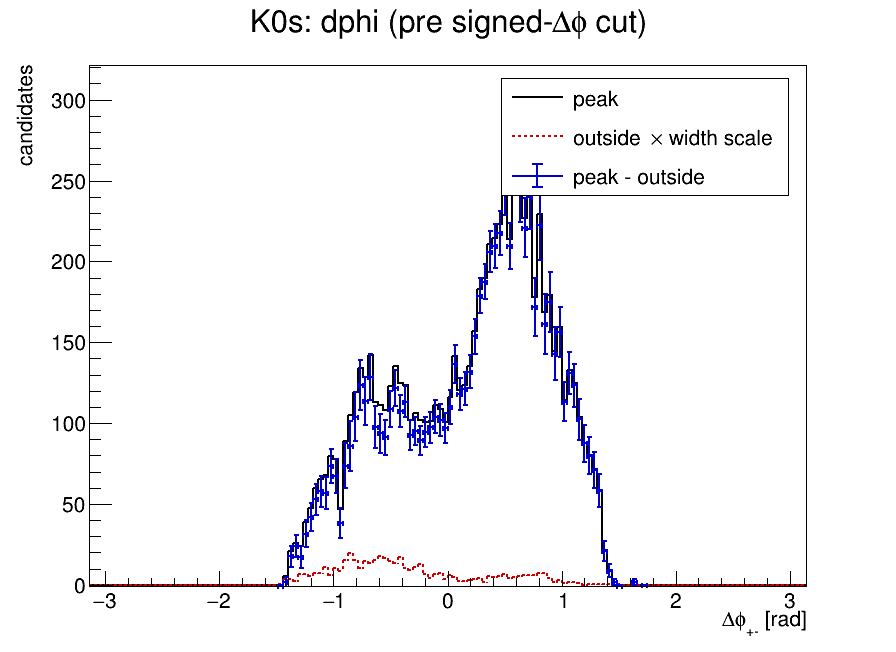

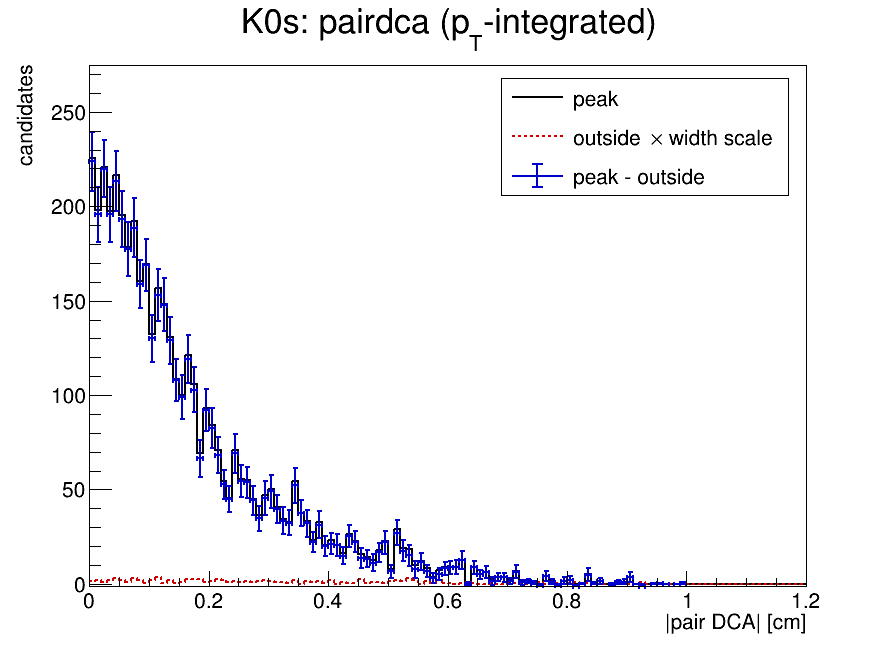

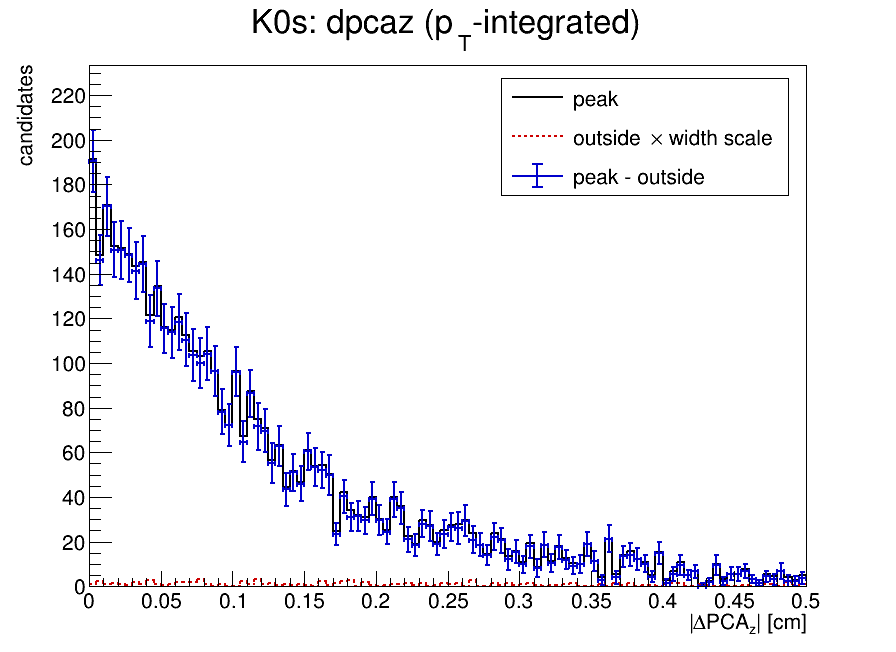

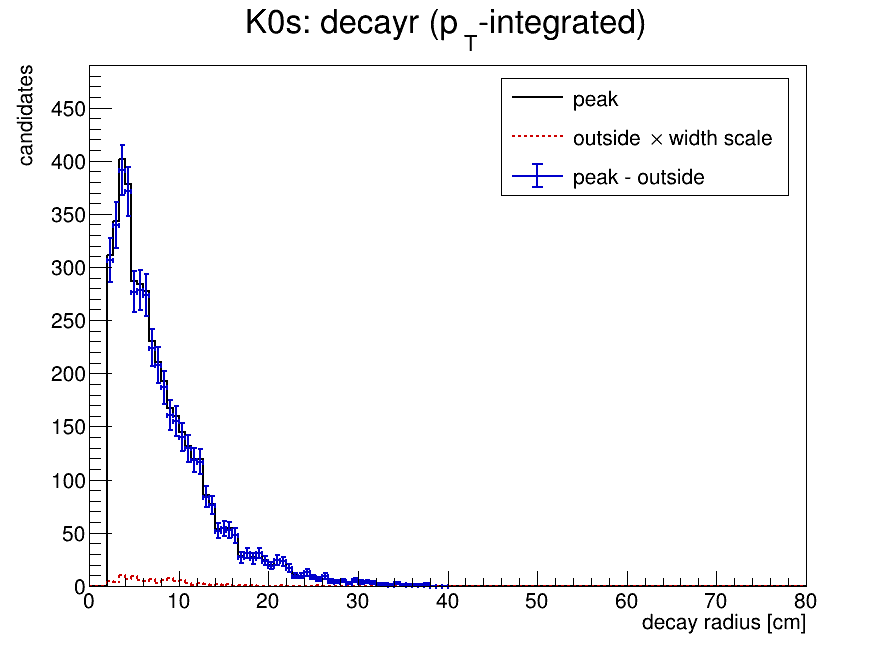

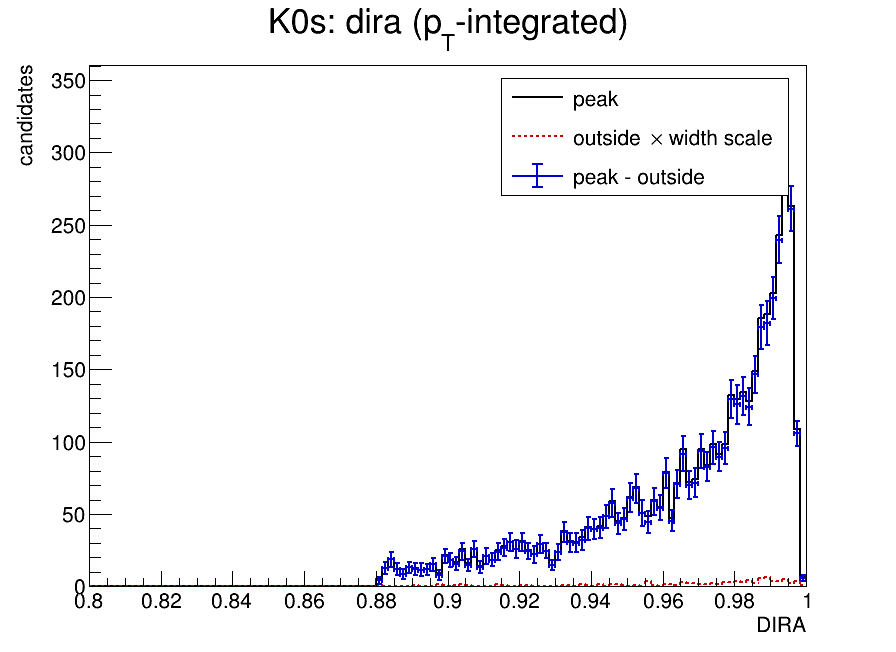

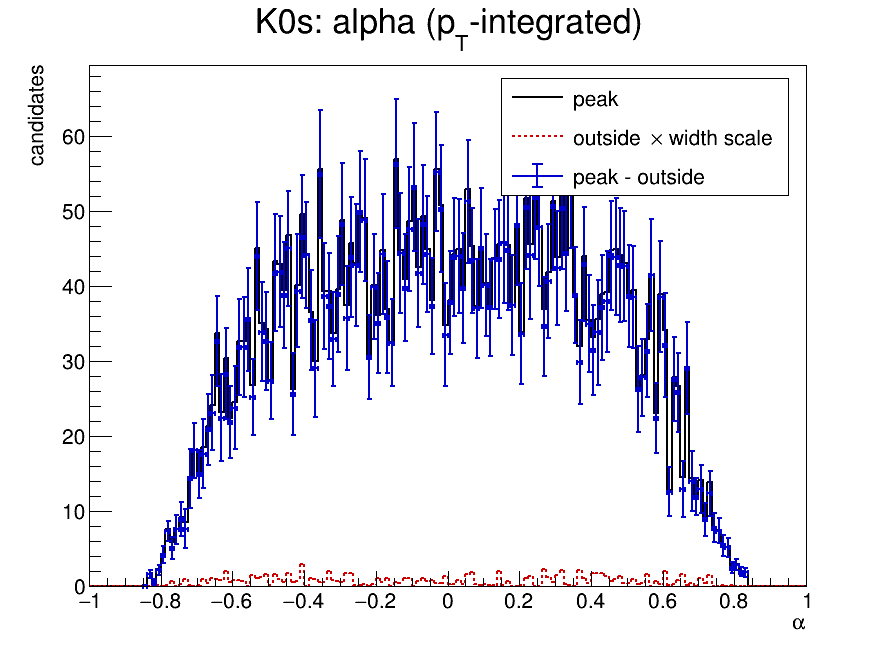

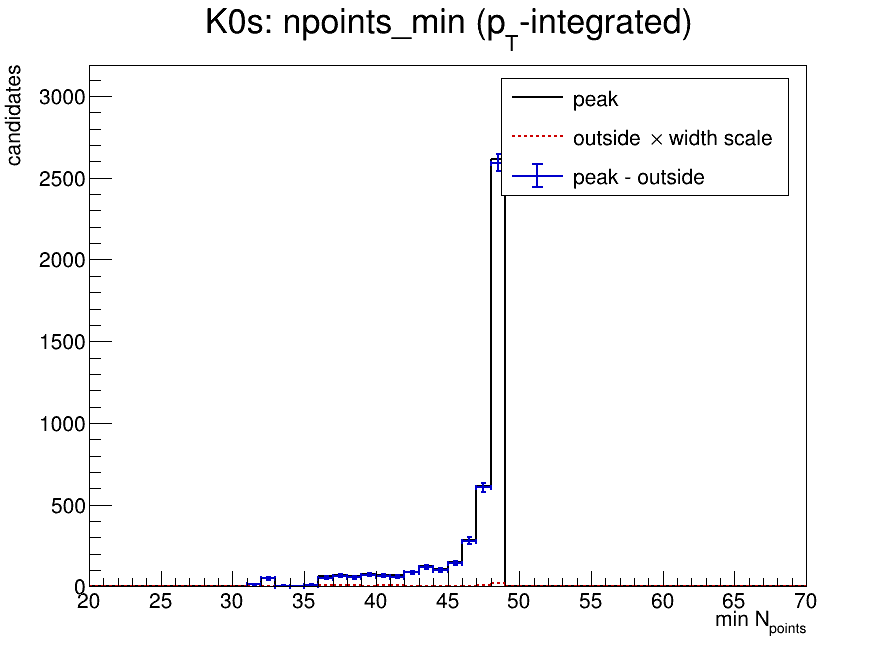

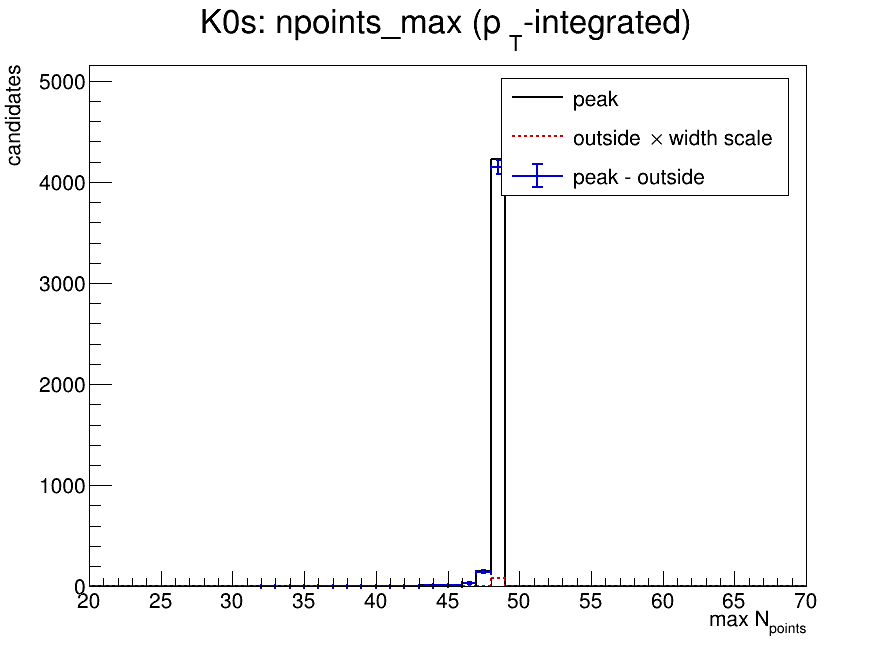

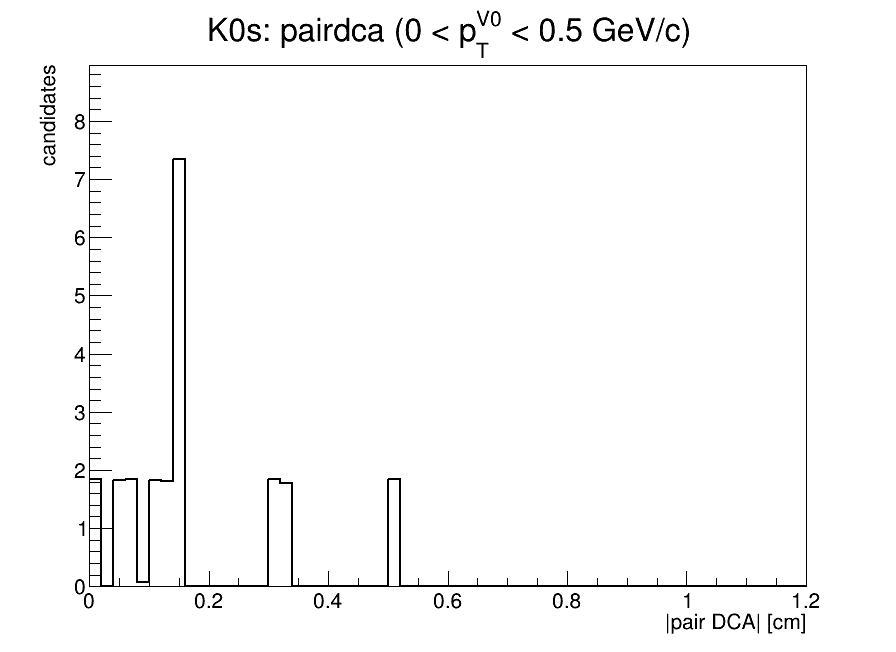

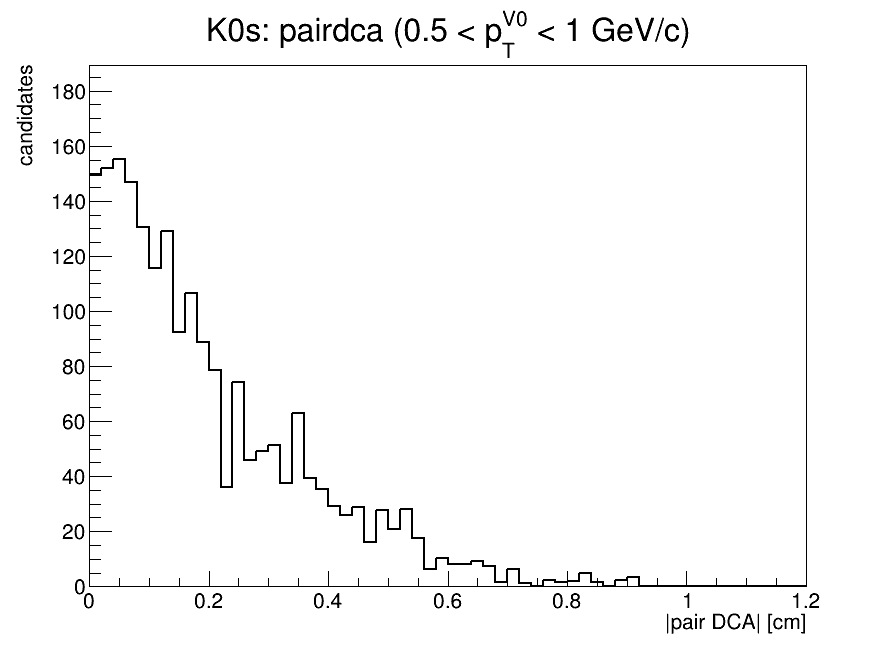

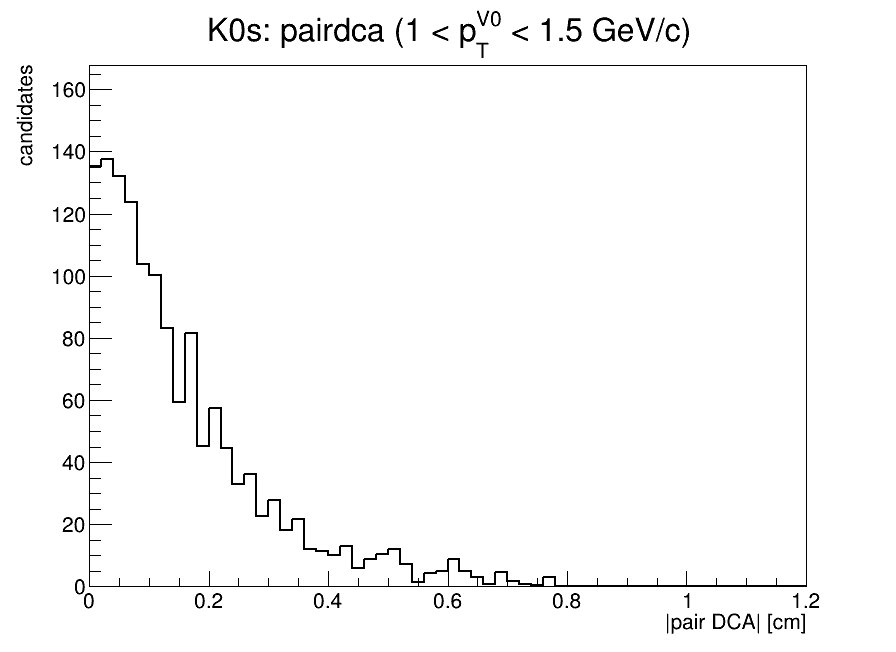

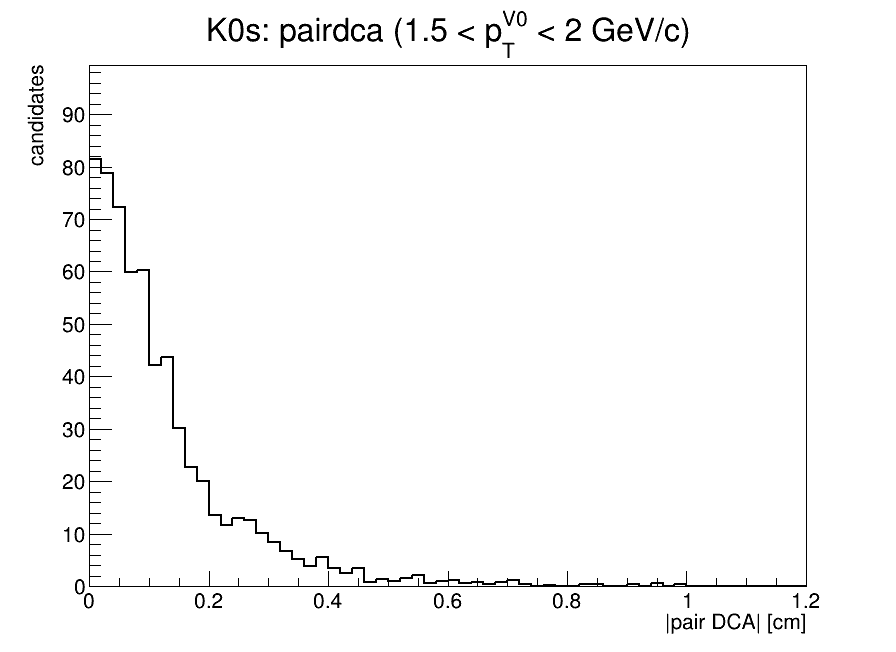

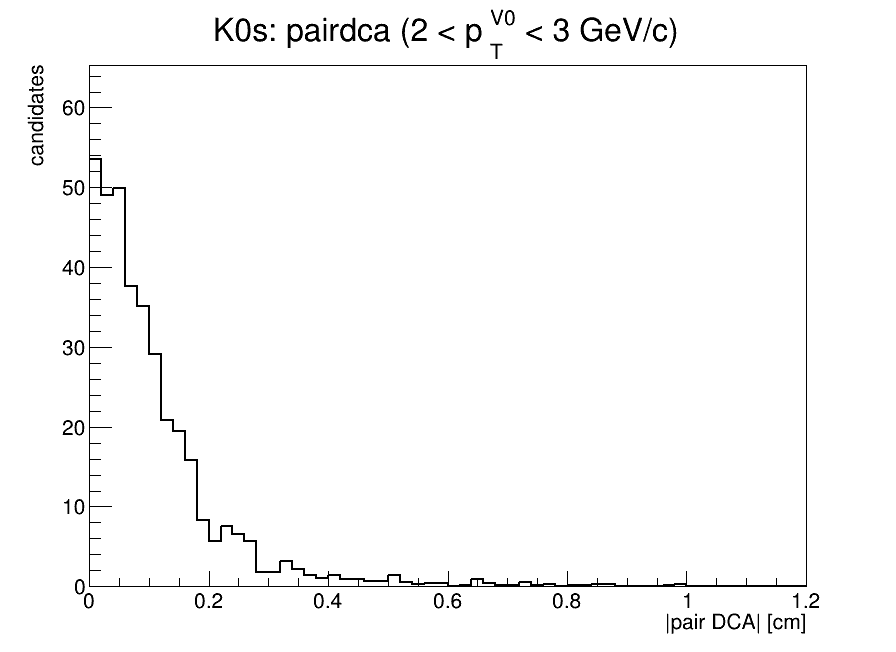

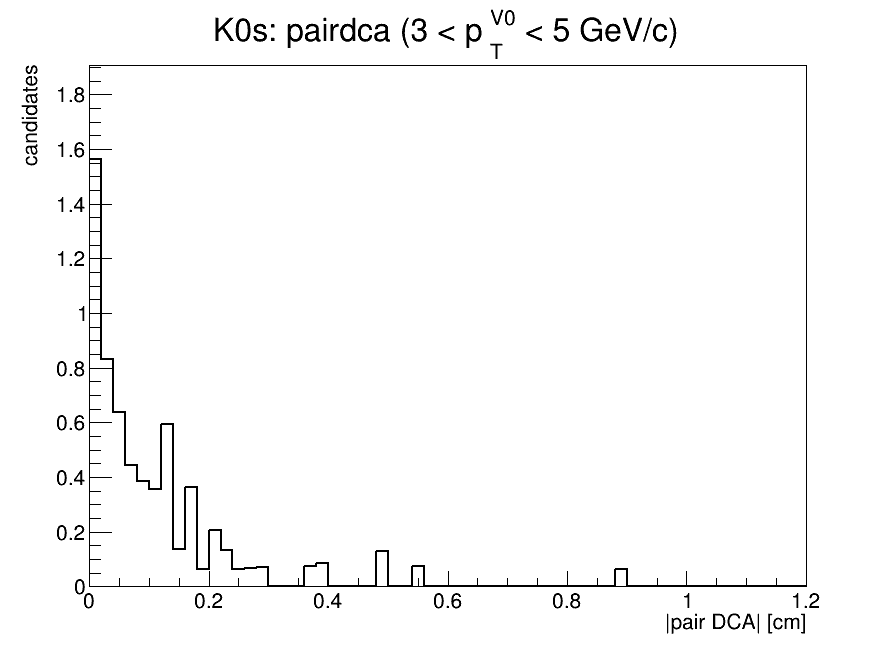

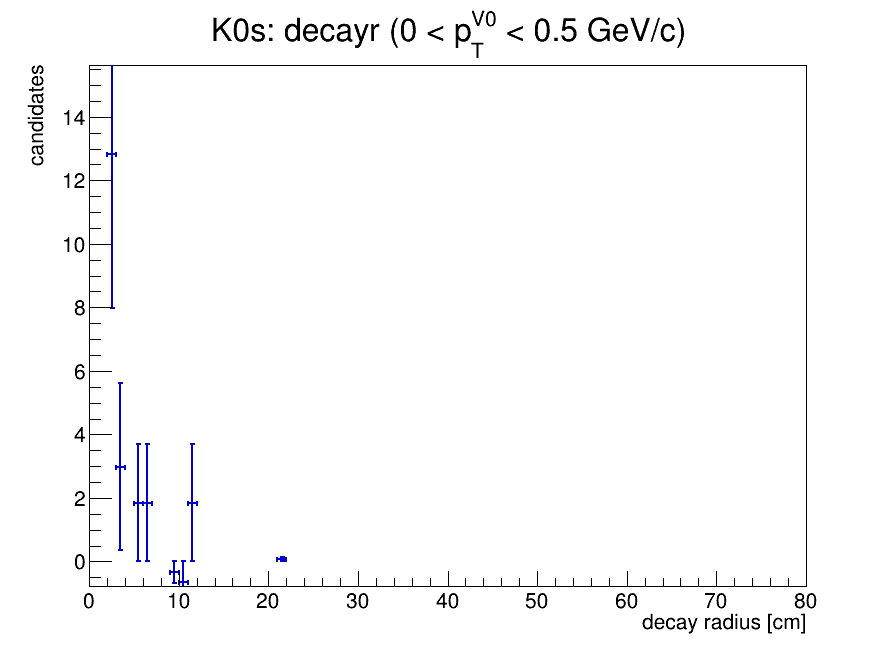

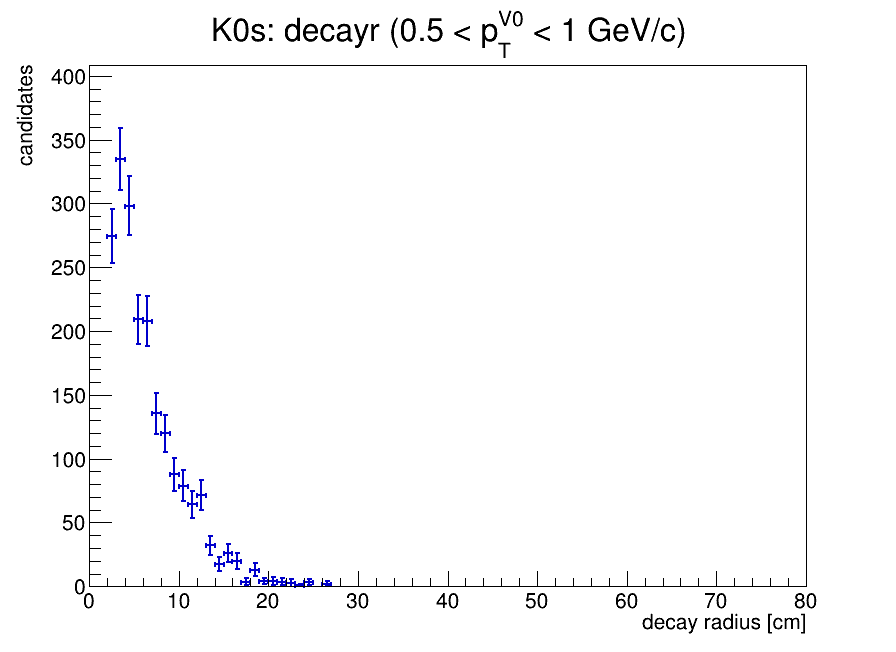

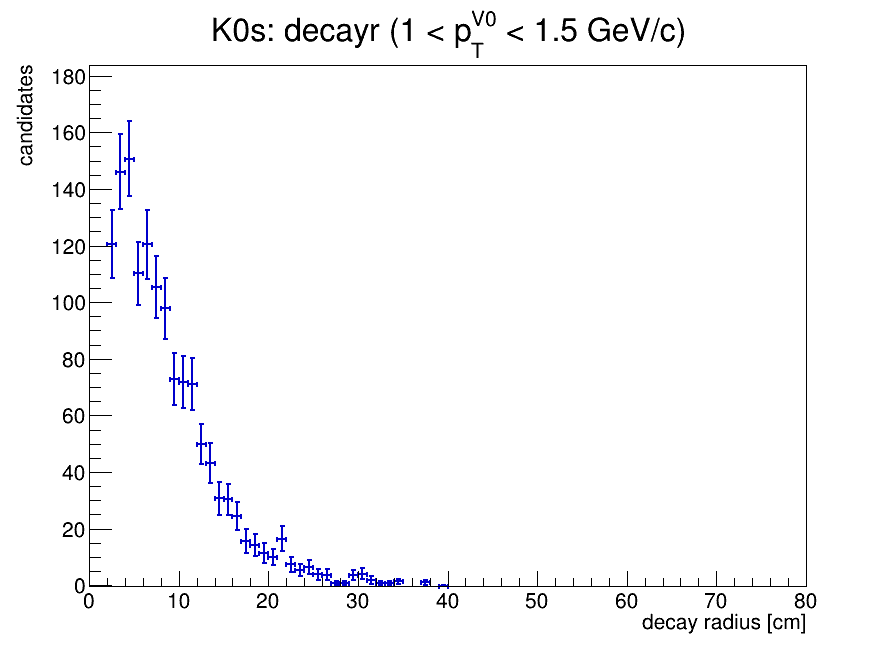

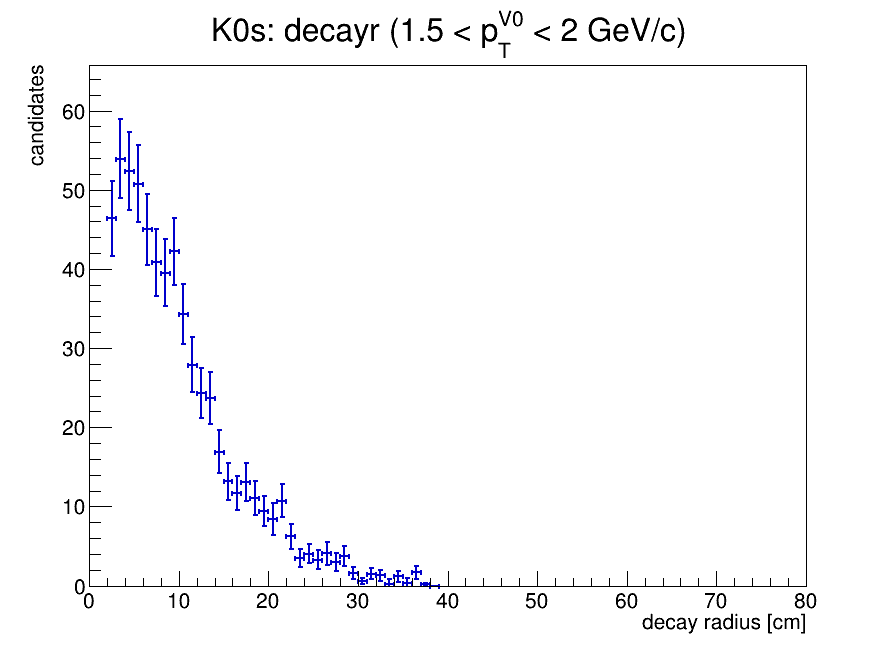

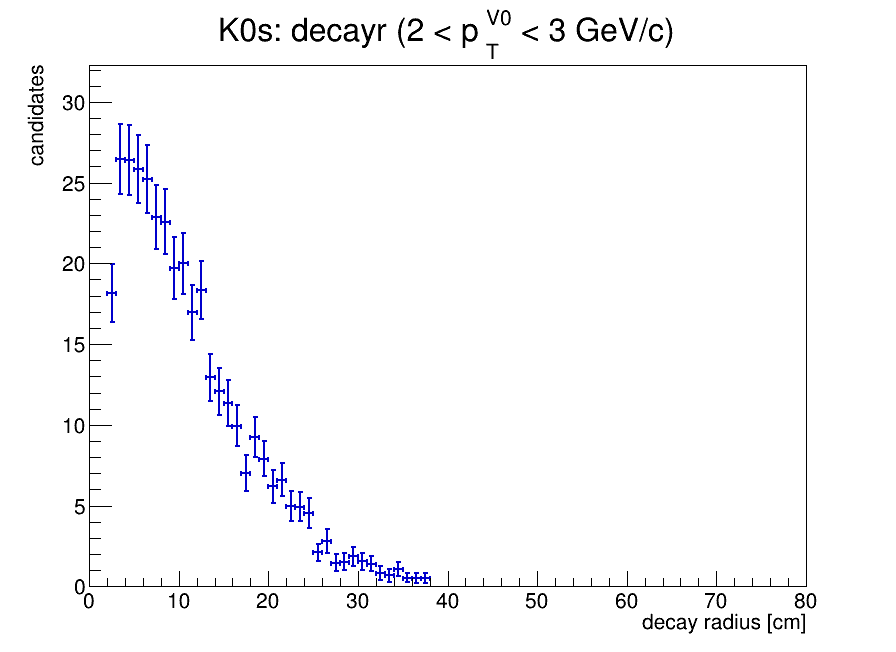

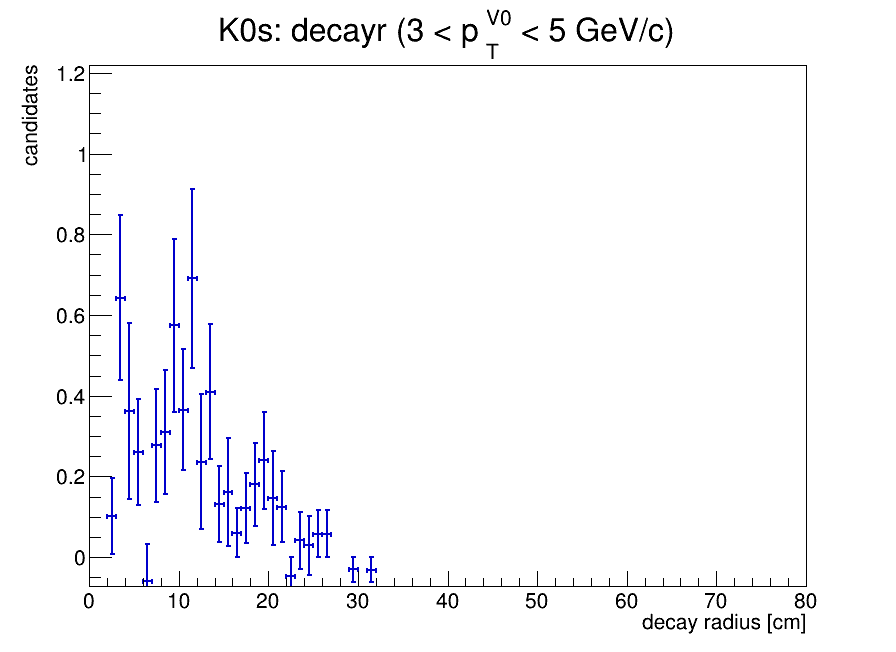

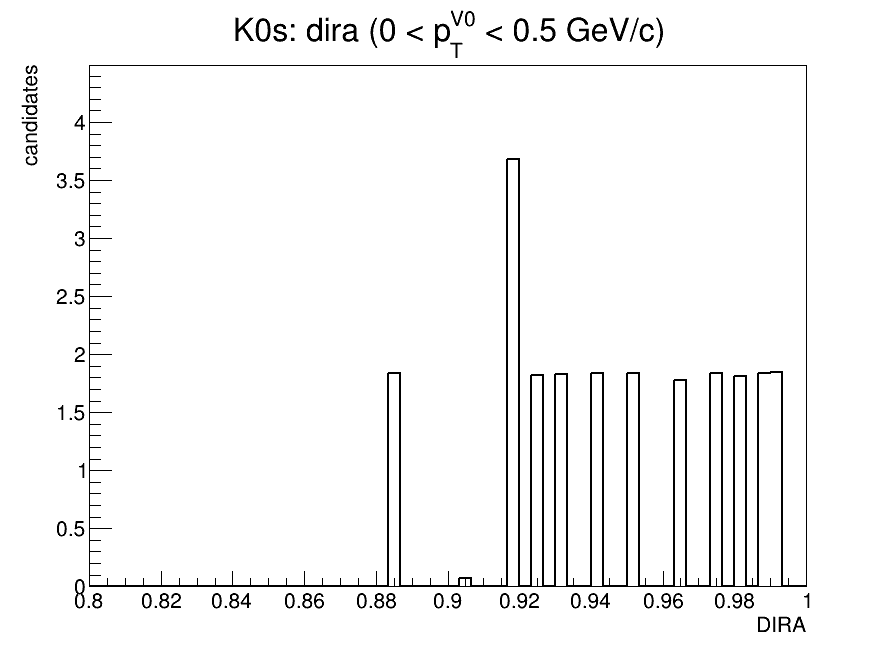

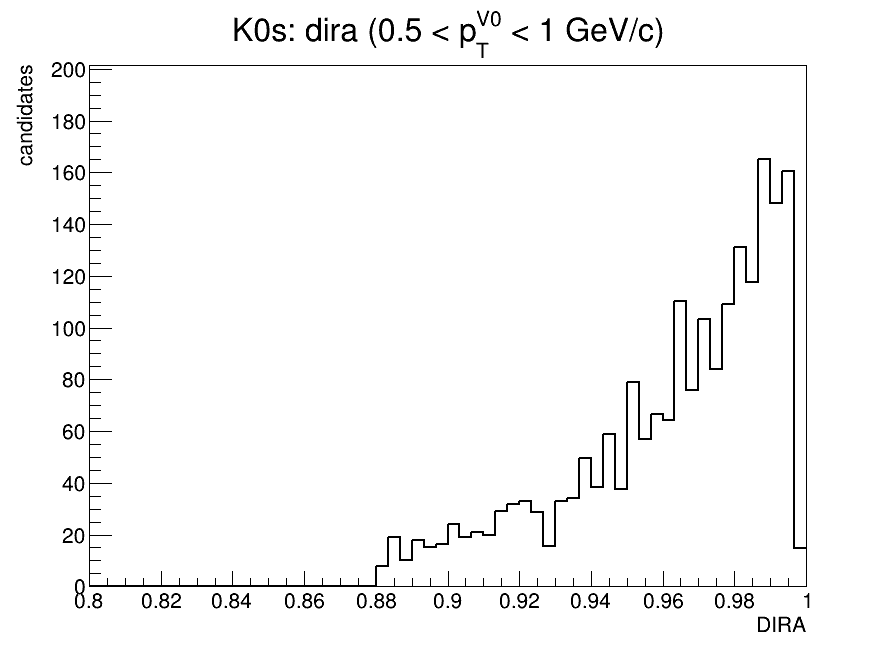

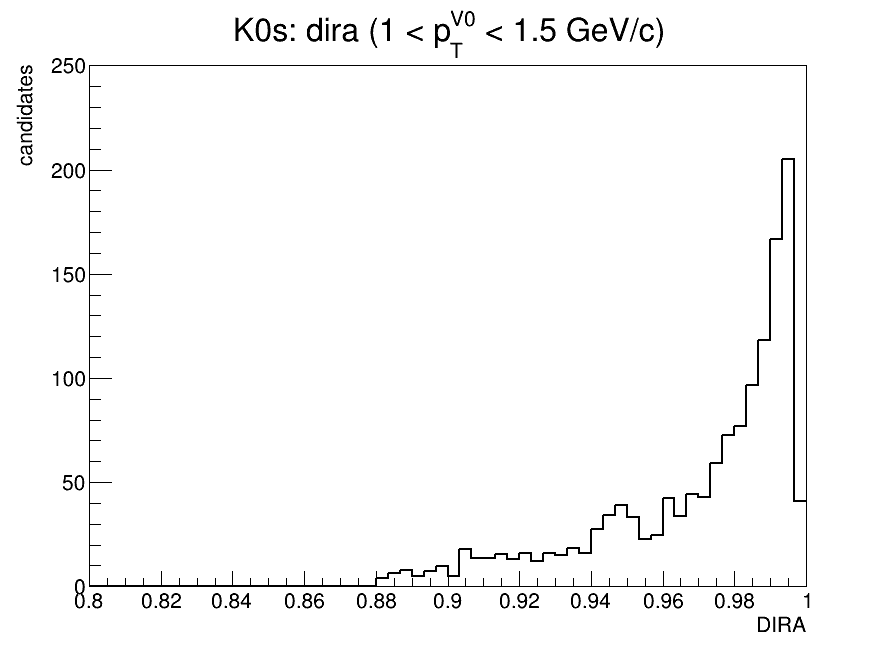

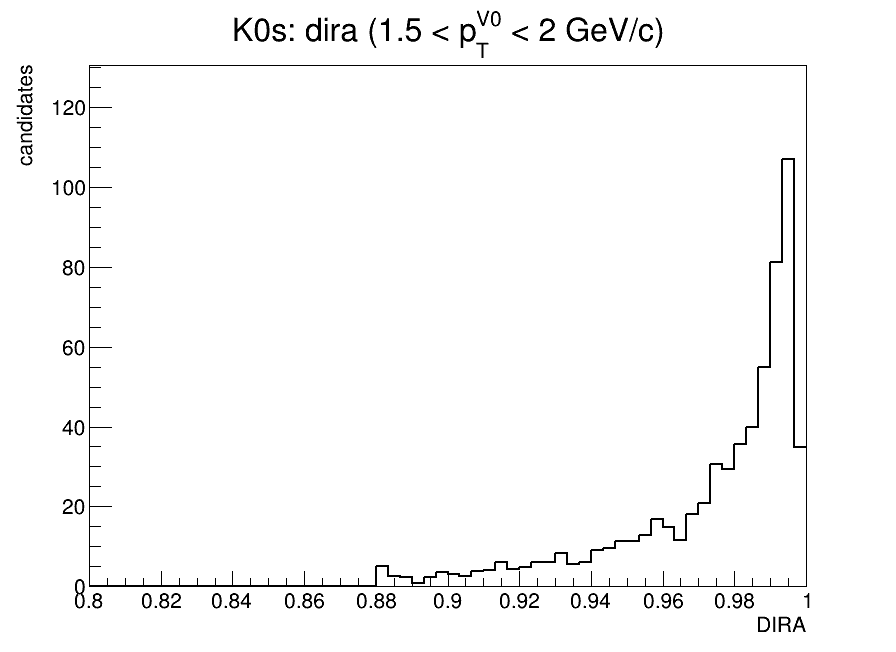

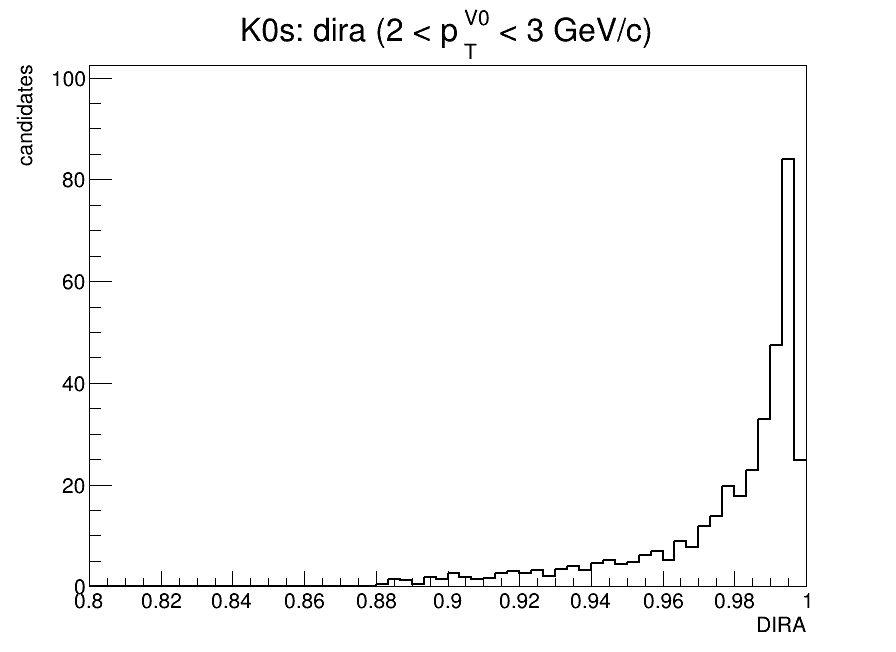

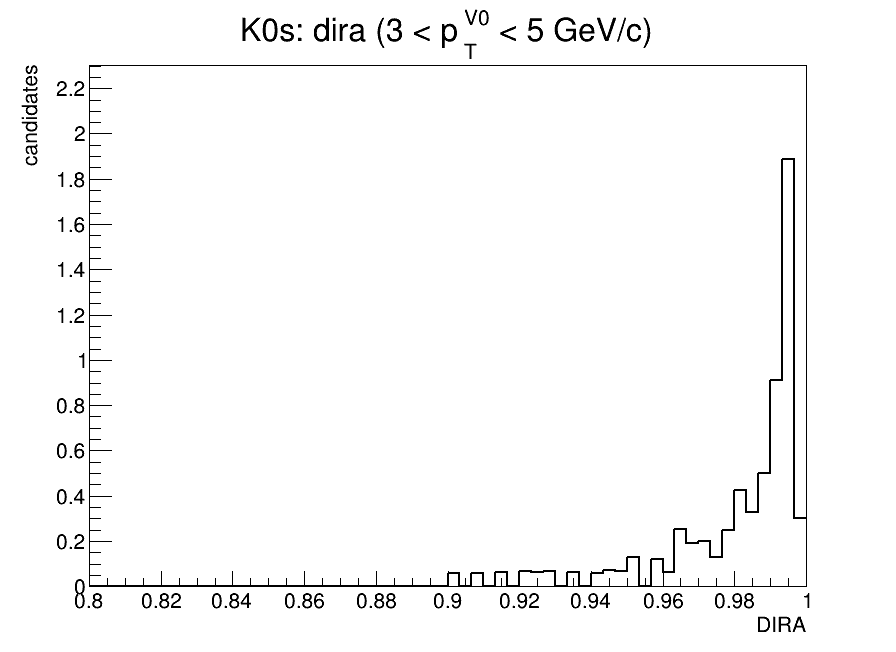

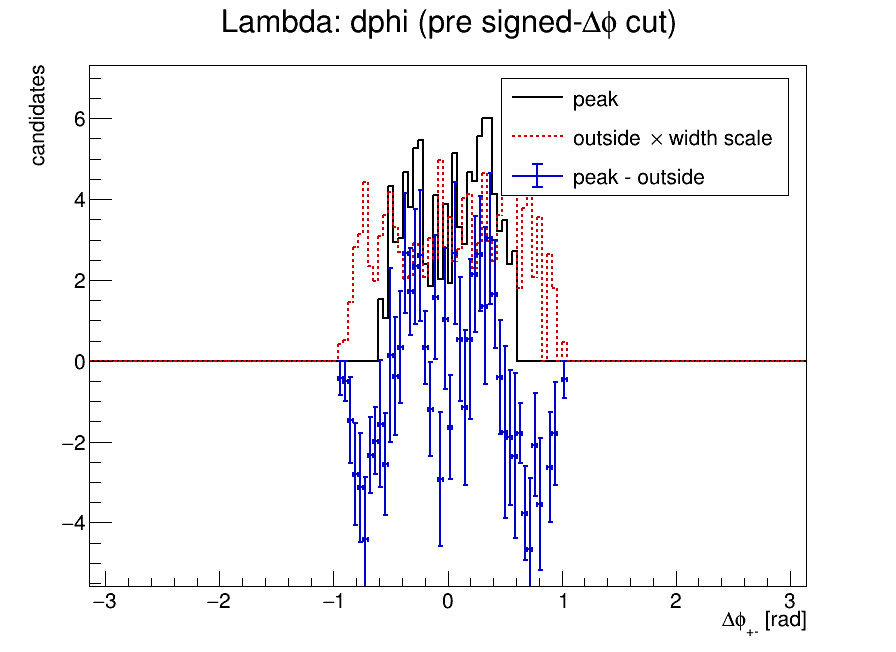

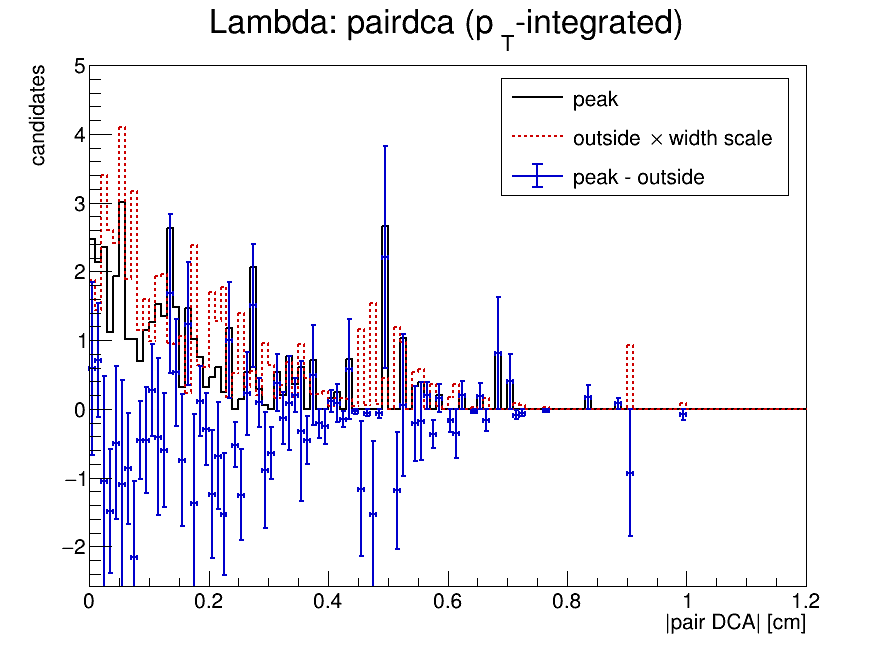

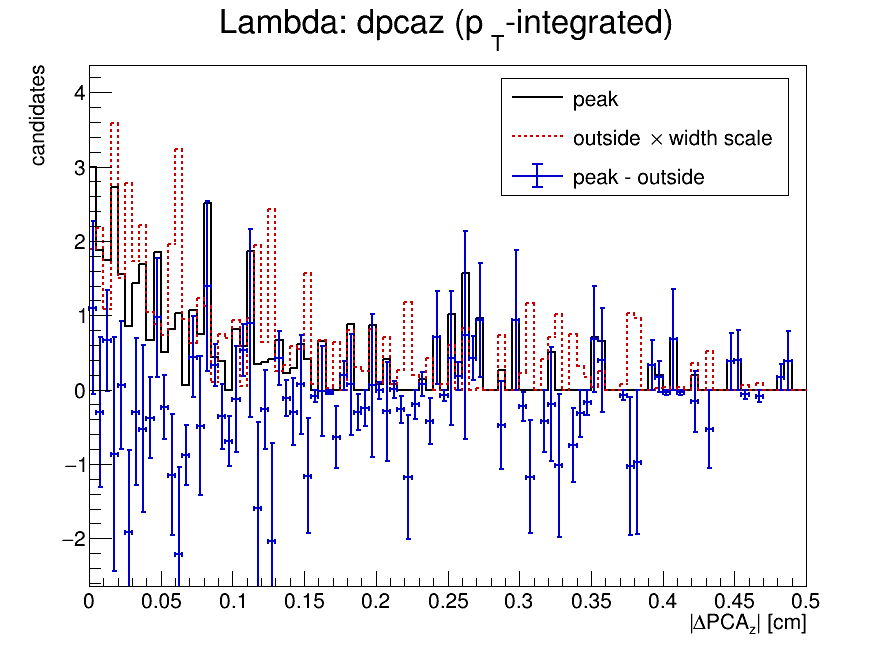

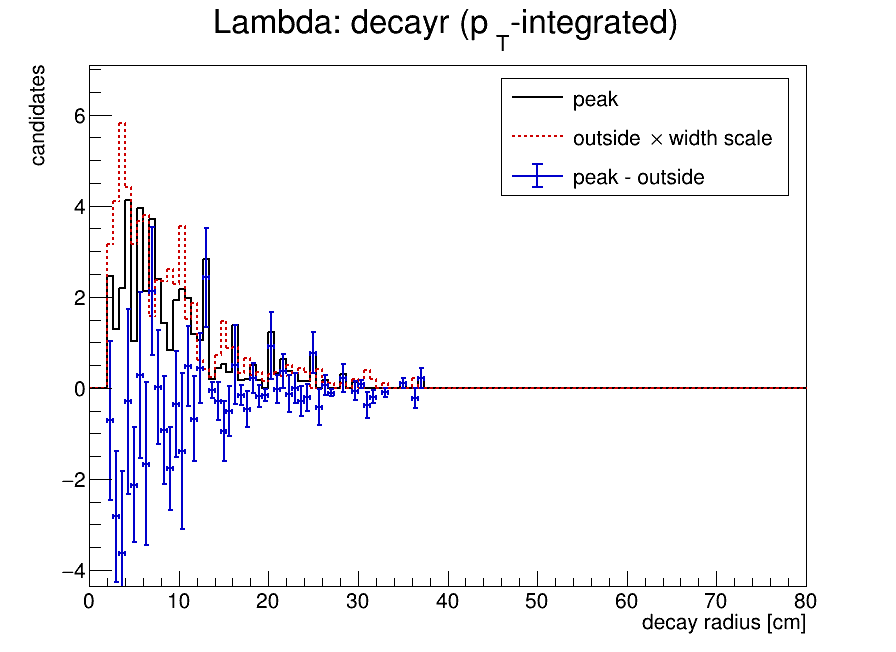

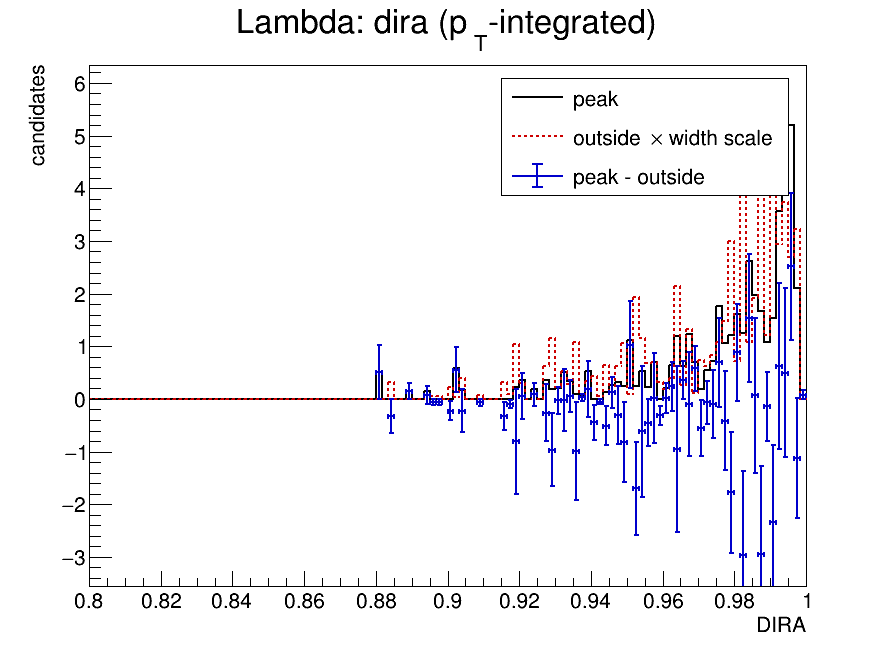

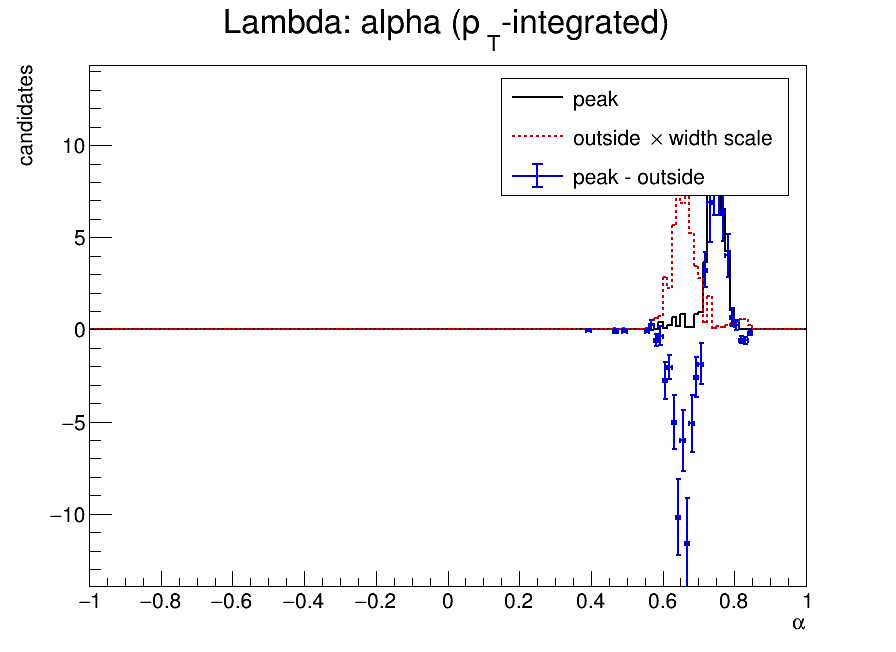

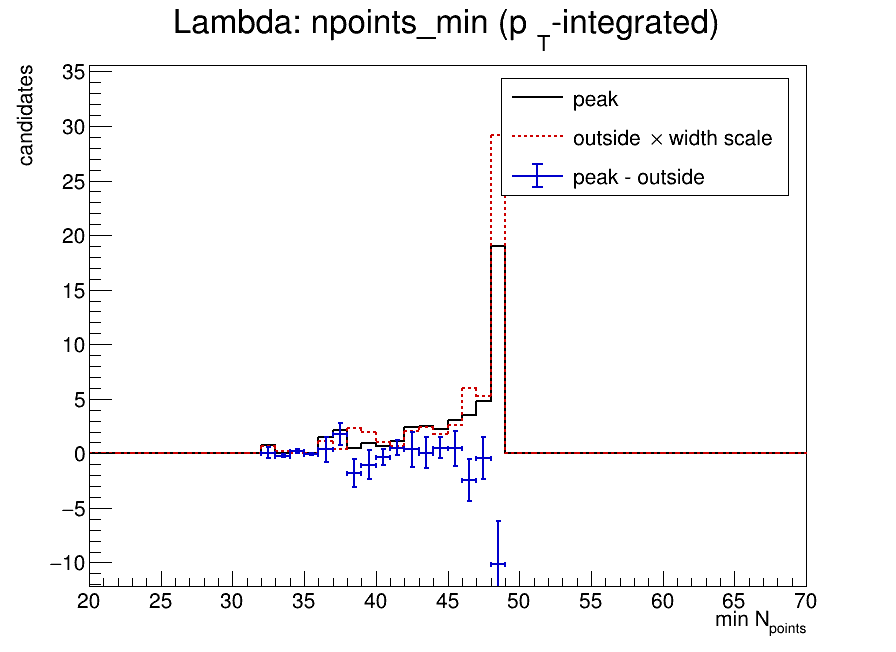

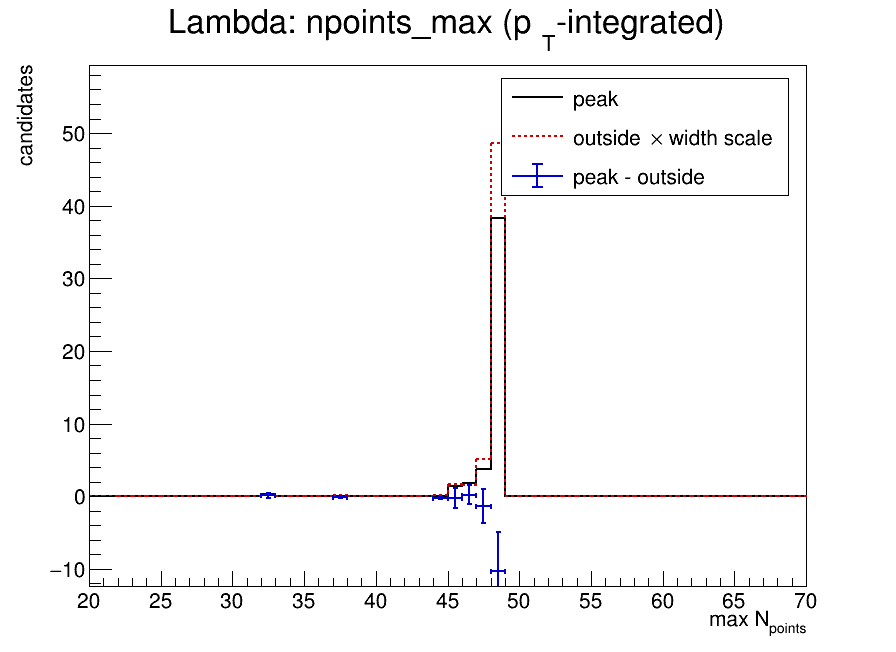

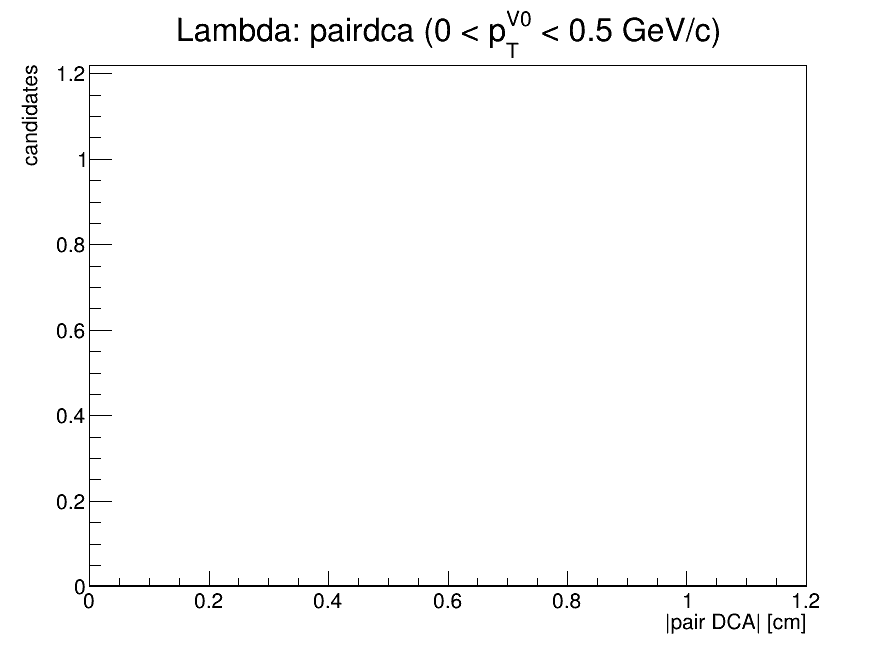

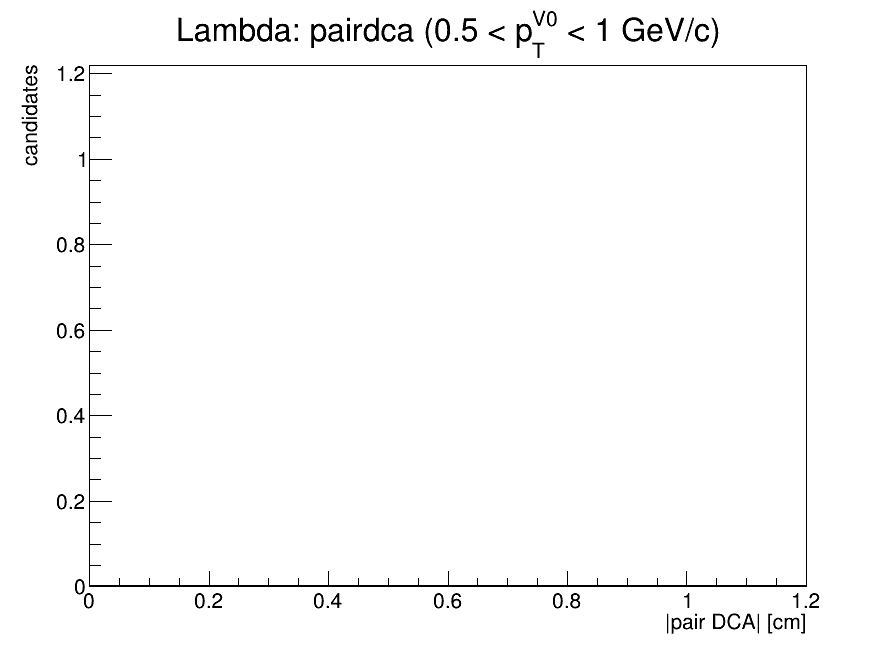

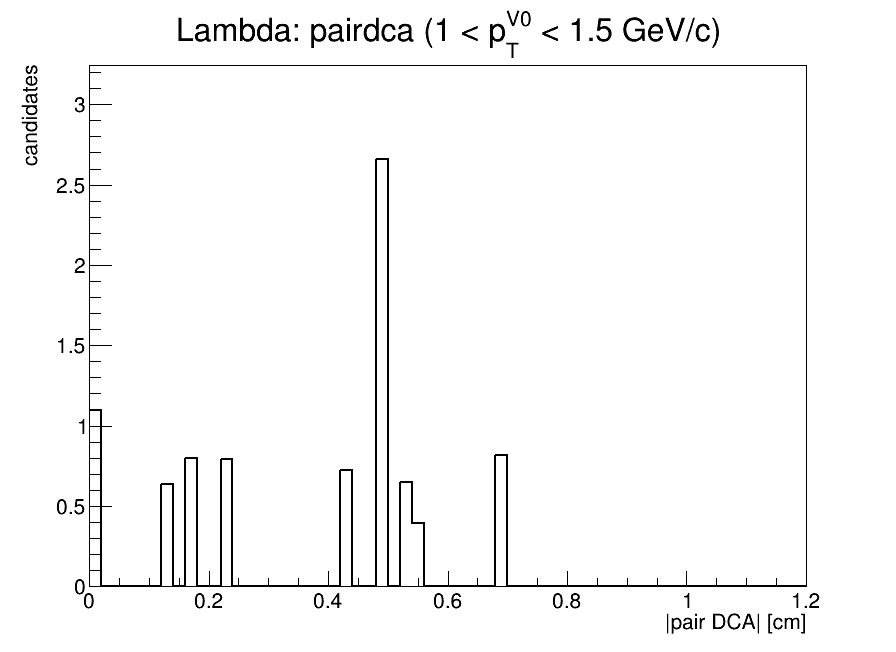

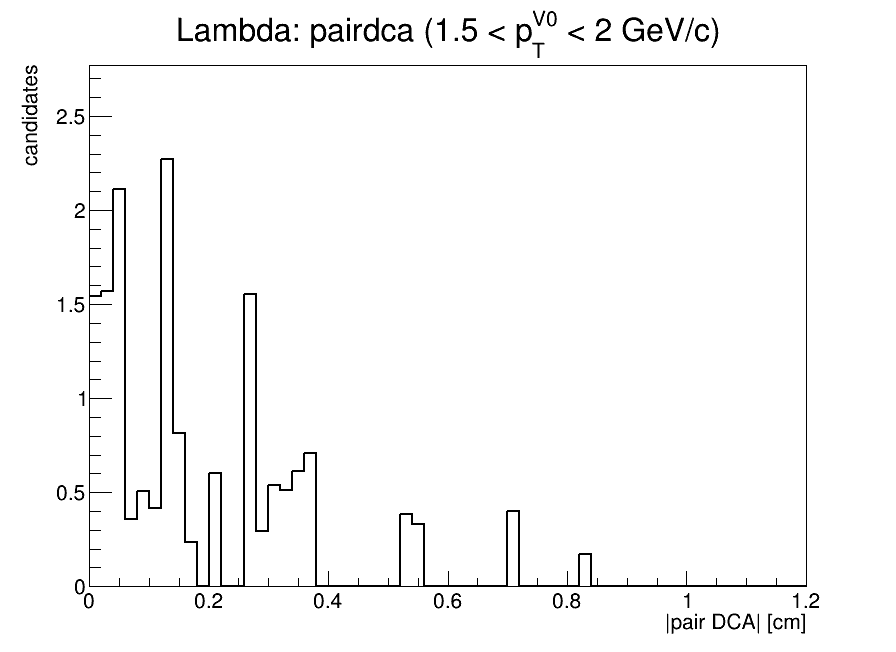

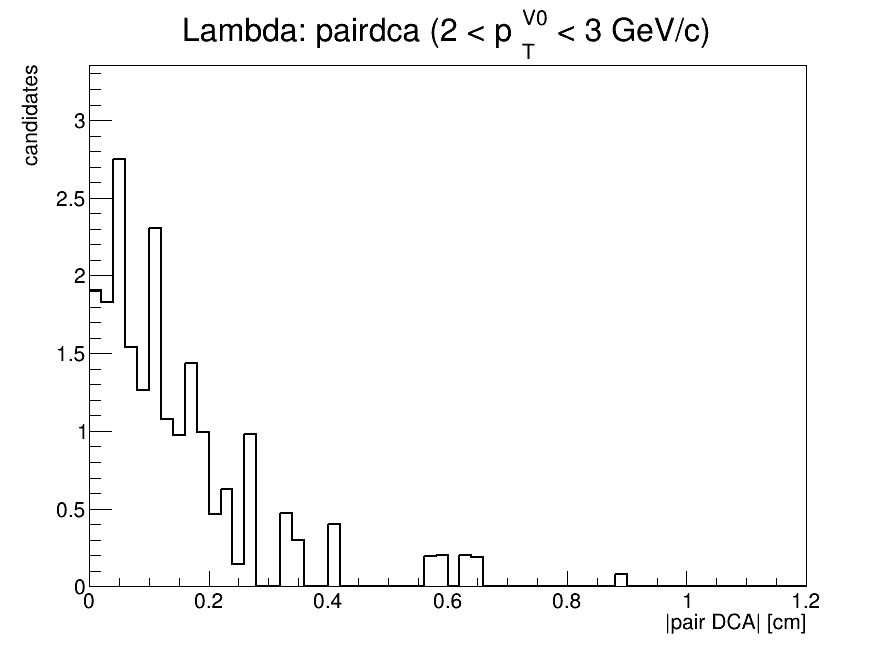

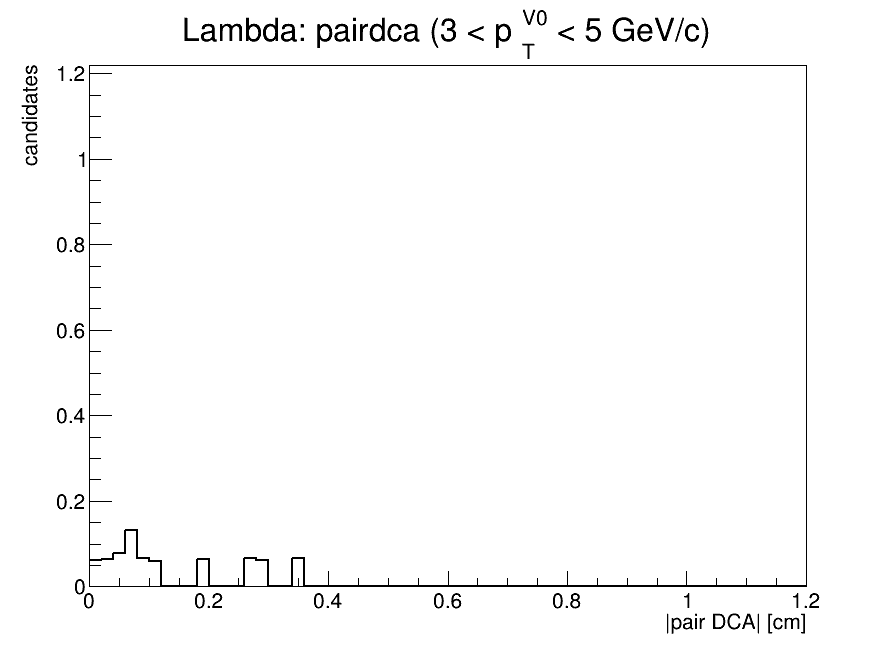

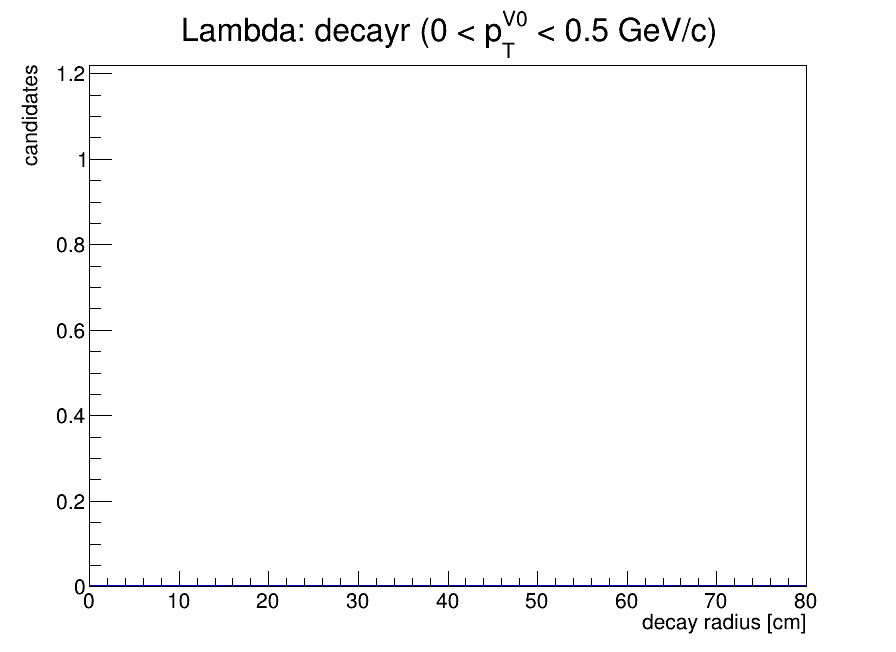

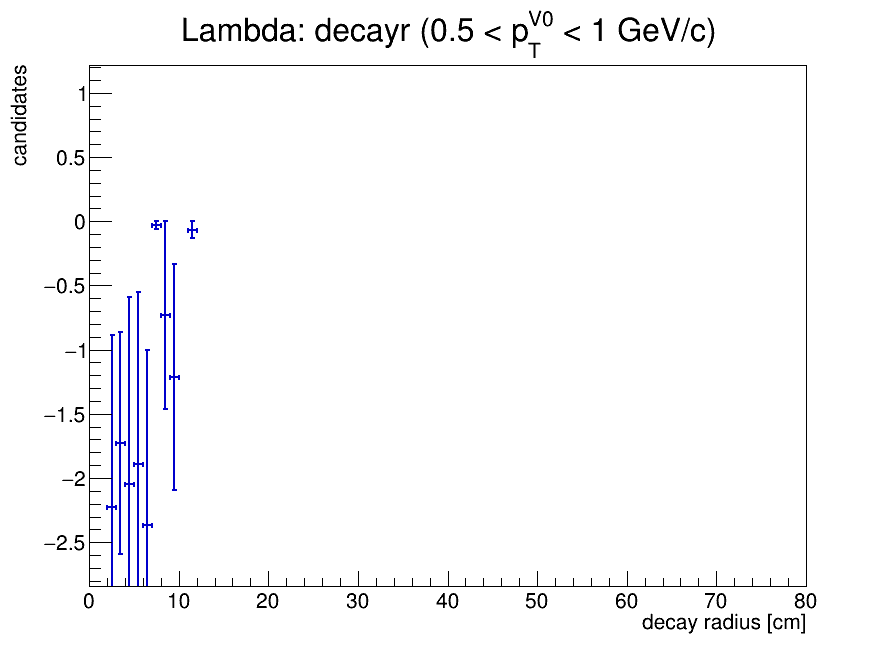

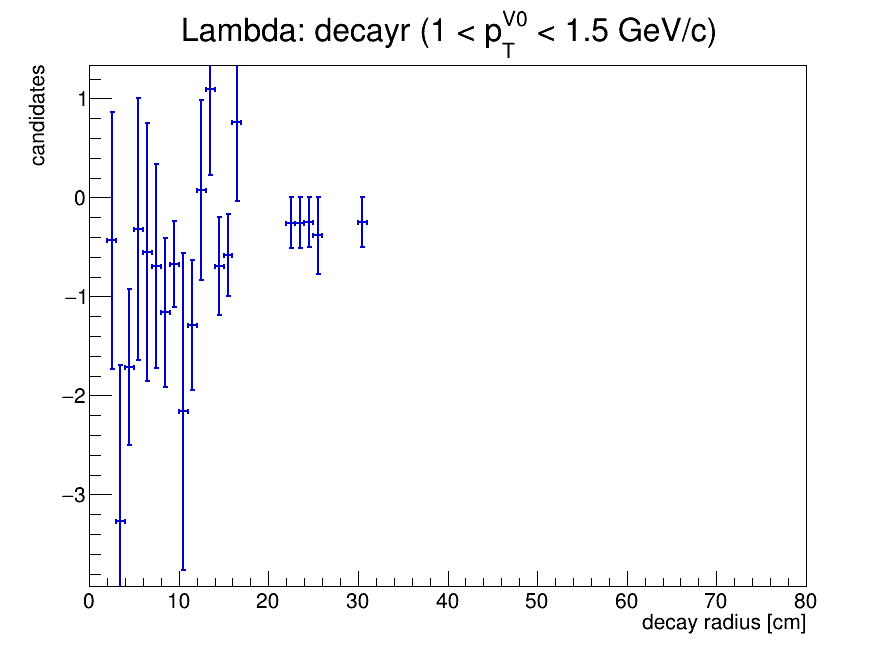

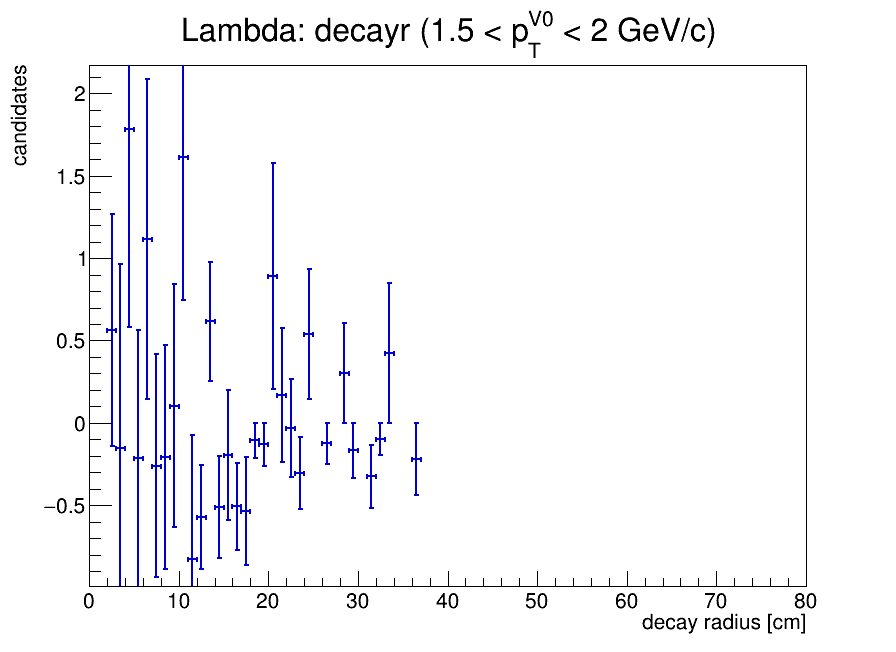

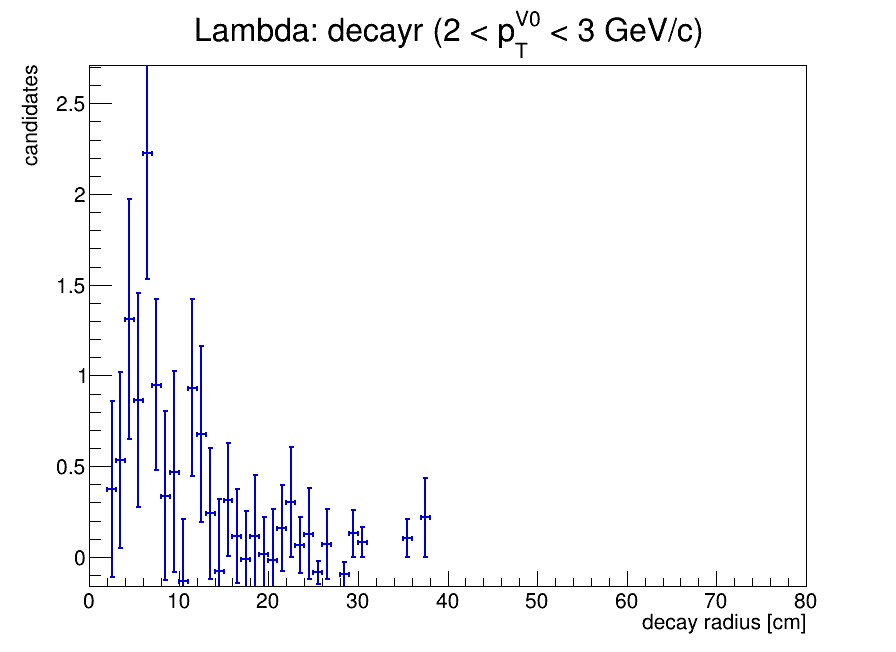

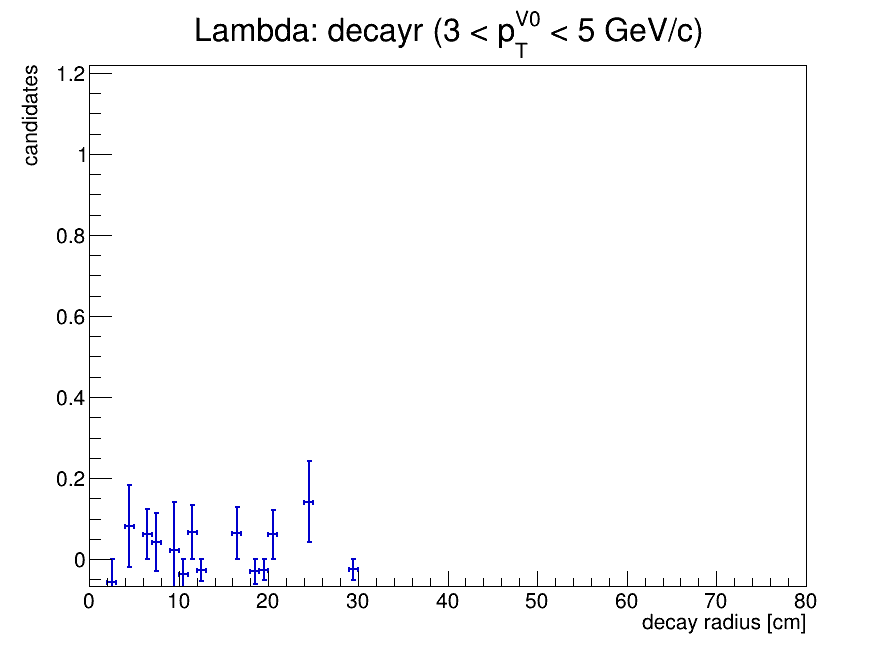

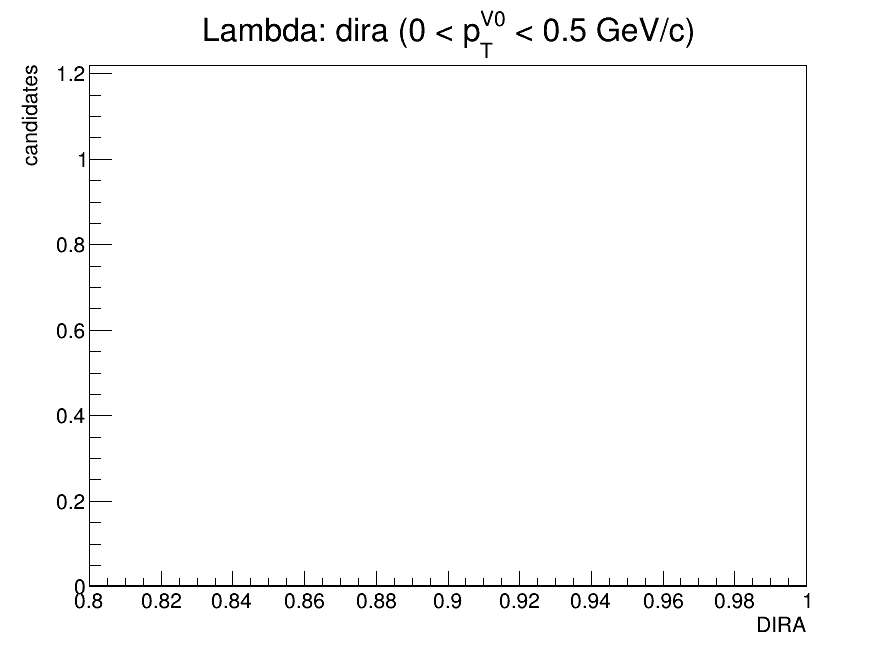

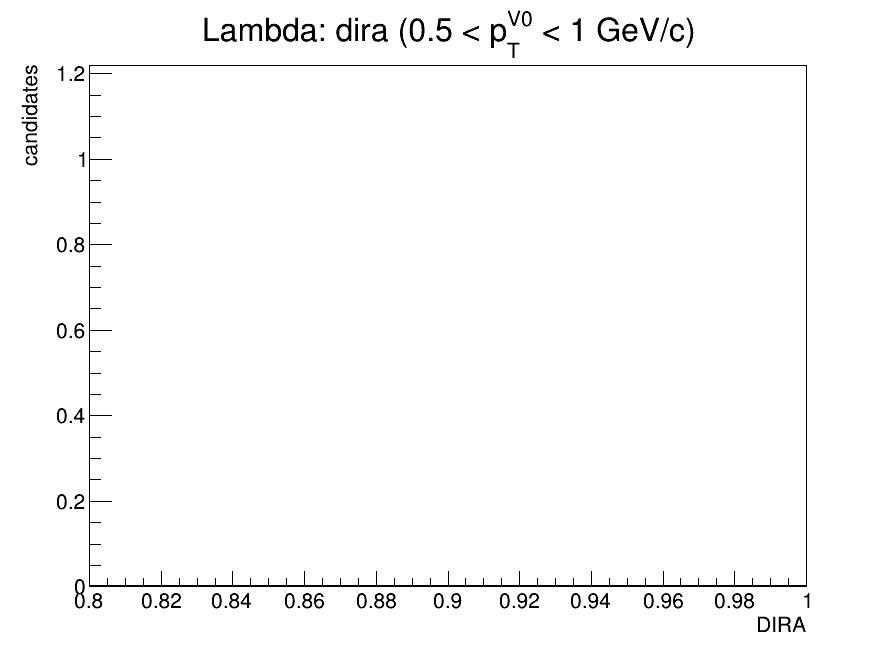

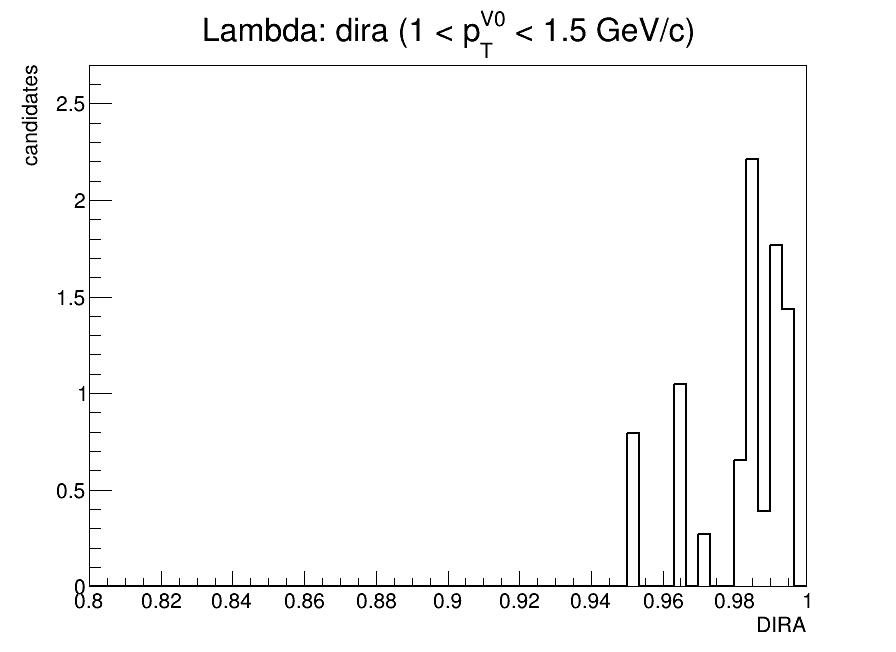

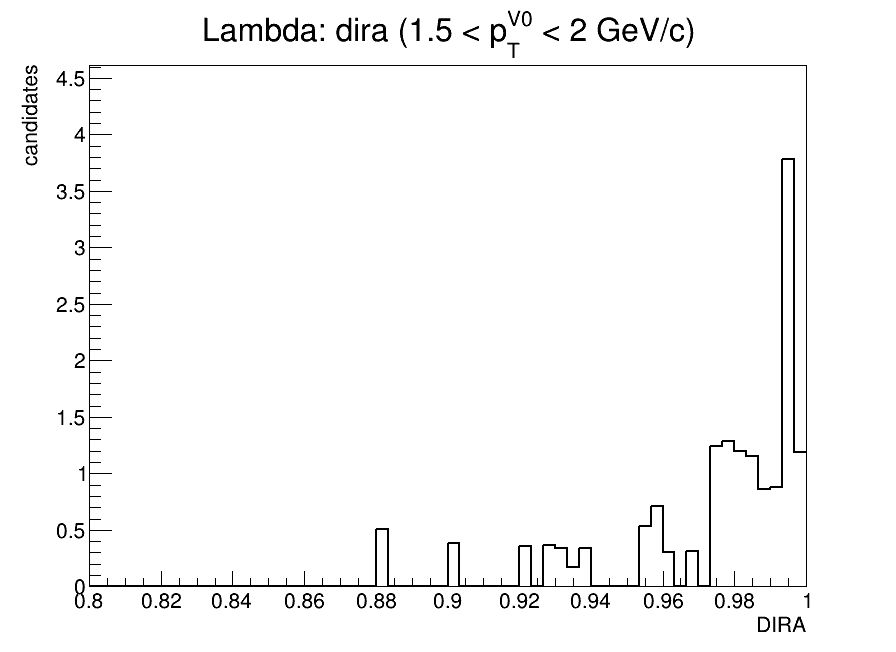

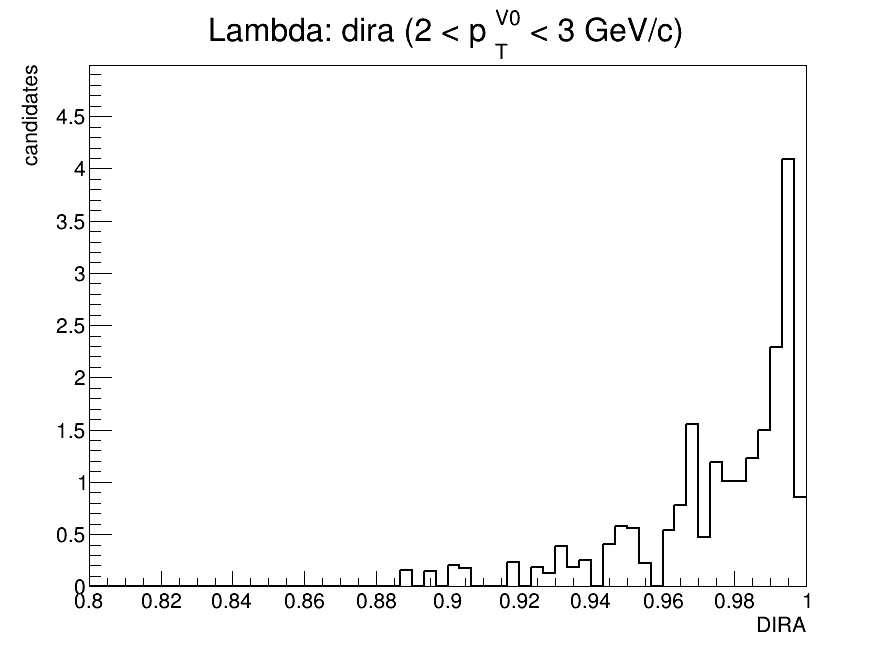

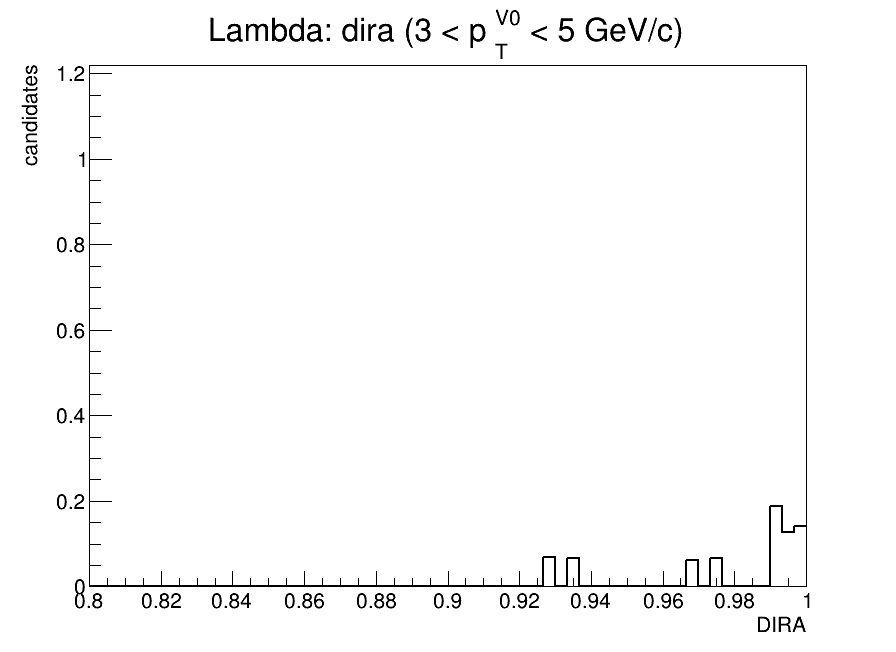

In [4]:
def parse(spec):
    p = spec.split(":")
    alias = p[0].strip()
    mode = p[1].strip() if len(p)>1 and p[1].strip() else "all"
    want_pt = len(p)>2 and p[2].strip().lower()=="pt"

    if alias not in ALIASES:
        raise KeyError(f"Unknown variable '{alias}'. Available: {', '.join(ALIASES)}")
    if mode not in ("all","pk","bg","sg"):
        raise ValueError(f"Bad mode '{mode}' in '{spec}'")
    return alias,mode,want_pt

pages = []
page_meta = []
warnings = []

for species in SPECIES:
    w = windows(species)
    print(f"\n{species}: peak={w['peak']}, sidebands={w['left']} + {w['right']}, scale={w['scale']:.6g}")

    for spec in PLOTS:
        alias,mode,want_pt = parse(spec)
        hname,kind = ALIASES[alias]

        if want_pt:
            if alias not in PT_MASS3:
                warnings.append(f"SKIP {species} {spec}: no mass x pT x variable histogram in this file")
                continue

            for pt in PT_BINS:
                hs = pt_triplet(species, alias, pt)
                print(f"  {spec:22s}  pT={pt}: pk[{hist_info(hs['pk'])}]  bg[{hist_info(hs['bg'])}]  sg[{hist_info(hs['sg'])}]")

                subtitle = f"{pt[0]:g} < p_{{T}}^{{V0}} < {pt[1]:g} GeV/c"
                c = draw_1d(species, alias, hs, mode, subtitle)
                tag = f"{alias}_{mode}_pt_{pt[0]:g}_{pt[1]:g}"

                # Keep page fully painted before serializing anything.
                pages.append(c)
                page_meta.append((species, tag, hs))
            continue

        if kind == "pre_dphi":
            hs = pre_dphi_triplet(species)
            c = draw_1d(species, alias, hs, mode, "pre signed-#Delta#phi cut")
        else:
            hs = regular_triplet(species, hname)
            subtitle = "p_{T}-integrated"
            c = draw_1d(species, alias, hs, mode, subtitle) if kind=="h1" else draw_2d(species, alias, hs, mode, subtitle)

        print(f"  {spec:22s}  pk[{hist_info(hs['pk'])}]  bg[{hist_info(hs['bg'])}]  sg[{hist_info(hs['sg'])}]")
        tag = f"{alias}_{mode}_integrated"
        pages.append(c)
        page_meta.append((species, tag, hs))

# First make the PDF from already-painted canvases.
print_pdf(pages, PDF)

# Then write the histograms and canvases to the ROOT file.
for c,(species,tag,hs) in zip(pages,page_meta):
    write_objects(species, tag, hs, c)

fout.Write()
fout.Close()

print(f"\nWrote {len(pages)} pages -> {PDF}")
print(f"Wrote derived histograms/canvases -> {ROOT_OUT}")

if warnings:
    print("\nWarnings:")
    for x in warnings:
        print("  ", x)

# Optional visual sanity check in Jupyter:
if SHOW and pages:
    display(pages[0])
